# Project I ArtBench-10
**Student:** Filipe de Castro Oliveira 2024131032


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted (Colab).')
except ModuleNotFoundError:
    print('Ambiente local detectado: sem google.colab.')
    print('Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.')

Ambiente local detectado: sem google.colab.
Use Google Drive for Desktop e ajuste GOOGLE_DRIVE_ROOT se necessário.


In [2]:
from __future__ import annotations

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths (Colab or local + Google Drive Desktop)
WORKSPACE_ROOT = Path.cwd()

def _is_usable_dir(p: Path) -> bool:
    try:
        return p.exists() and p.is_dir()
    except OSError:
        return False

if "google.colab" in sys.modules:
    PROJECT_ROOT = Path('/content/drive/MyDrive/MIACD - GAI')
else:
    # Opcional: setar no terminal -> $env:GOOGLE_DRIVE_ROOT='G:/My Drive/MIACD - GAI'
    _env_drive_root = os.environ.get('GOOGLE_DRIVE_ROOT', '').strip()
    _candidates = []
    if _env_drive_root:
        _candidates.append(Path(_env_drive_root).expanduser())
    _candidates += [
        Path('G:/My Drive/MIACD - GAI'),
        Path.home() / 'My Drive' / 'MIACD - GAI',
        Path.home() / 'Google Drive' / 'My Drive' / 'MIACD - GAI',
        WORKSPACE_ROOT / 'drive_outputs',
    ]
    PROJECT_ROOT = next((p for p in _candidates if _is_usable_dir(p)), _candidates[-1])

# Prefer scripts from workspace; fallback to drive root
SCRIPTS_DIR = WORKSPACE_ROOT / 'scripts'
if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    SCRIPTS_DIR = PROJECT_ROOT / 'scripts'

EXPORT_ROOT = PROJECT_ROOT / 'exported_data'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

if not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        f"Could not resolve scripts folder. Tried: {WORKSPACE_ROOT / 'scripts'} and {PROJECT_ROOT / 'scripts'}"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('PROJECT_ROOT   =', PROJECT_ROOT)
print('SCRIPTS_DIR    =', SCRIPTS_DIR)
print('EXPORT_ROOT    =', EXPORT_ROOT)

WORKSPACE_ROOT = c:\Users\User\source\repos\genai-project1
PROJECT_ROOT   = c:\Users\User\source\repos\genai-project1\drive_outputs
SCRIPTS_DIR    = c:\Users\User\source\repos\genai-project1\scripts
EXPORT_ROOT    = c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data


In [4]:
import kagglehub
import os

def _is_artbench_root(p: Path) -> bool:
    p = Path(p)
    return (p / 'ArtBench-10.csv').exists() and (p / 'artbench-10-python').exists()

# 1) Try to reuse existing local dataset first
candidate_roots = []

if 'KAGGLE_ROOT' in globals() and KAGGLE_ROOT is not None:
    candidate_roots.append(Path(KAGGLE_ROOT))

if 'PROJECT_ROOT' in globals():
    candidate_roots += [
        Path(PROJECT_ROOT),
        Path(PROJECT_ROOT) / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'datasets' / 'ArtBench-10',
        Path(PROJECT_ROOT) / 'data' / 'ArtBench-10',
    ]

if 'WORKSPACE_ROOT' in globals():
    candidate_roots += [
        Path(WORKSPACE_ROOT),
        Path(WORKSPACE_ROOT) / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'datasets' / 'ArtBench-10',
        Path(WORKSPACE_ROOT) / 'data' / 'ArtBench-10',
    ]

KAGGLE_ROOT = next((p for p in candidate_roots if _is_artbench_root(p)), None)

if KAGGLE_ROOT is not None:
    print(f"Dataset já existe localmente. Pulando download.")
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")
else:
    # 2) Fallback: download using kagglehub
    print("Downloading ArtBench-10 dataset using kagglehub...")
    download_base_path = kagglehub.dataset_download("alexanderliao/artbench10")
    print(f"Dataset downloaded to: {download_base_path}")

    found_root = None
    for root, dirs, files in os.walk(download_base_path):
        if 'ArtBench-10.csv' in files and 'artbench-10-python' in dirs:
            found_root = Path(root)
            break

    if found_root is None:
        raise FileNotFoundError(
            "Could not find the 'ArtBench-10' root directory within the downloaded KaggleHub dataset."
        )

    KAGGLE_ROOT = found_root
    print(f"Set KAGGLE_ROOT to: {KAGGLE_ROOT}")

# This cell now reuses local data when available; otherwise it downloads.

c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2
Set KAGGLE_ROOT to: C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2


In [5]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='C:\Users\User\.cache\kagglehub\datasets\alexanderliao\artbench10\versions\2'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [6]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [7]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

train_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),  # outputs [0,1]
])

val_transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

transform = train_transform  # backward-compat alias


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=train_transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv`

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [8]:
import csv
import numpy as np
from torch.utils.data import DataLoader

# =========================
# Config
# =========================
INDEX_COLUMN = 'train_id_original'

# Resolve training_20_percent.csv with robust fallbacks
_csv_candidates = [
    WORKSPACE_ROOT / 'scripts' / 'training_20_percent.csv',
    PROJECT_ROOT / 'scripts' / 'training_20_percent.csv',
    SCRIPTS_DIR / 'training_20_percent.csv',
]
TRAINING_CSV_PATH = next((p for p in _csv_candidates if p.exists()), _csv_candidates[0])
print(f"Using TRAINING_CSV_PATH: {TRAINING_CSV_PATH}")

# =========================
# Load IDs
# =========================
def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training_20_percent.csv not found: {csv_path}\n"
            f"Tried candidates: {_csv_candidates}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)

print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])


# =========================
# Datasets — use ALL 20% subset for training (no val split, same as reference)
# =========================
train_ds_from_csv = HFDatasetTorch(
    train_hf,
    transform=transform,
    indices=train_ids_from_csv,
)

# Test set for FID/KID evaluation (held-out, never used for training)
test_hf = hf_ds["test"]
test_ds = HFDatasetTorch(test_hf, transform=transform, indices=None)


# =========================
# DataLoaders
# =========================
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Train dataset length:', len(train_ds_from_csv))
print('Test dataset length :', len(test_ds))
print('Train batches       :', len(train_loader_from_csv))
print('Test batches        :', len(test_loader))


Using TRAINING_CSV_PATH: c:\Users\User\source\repos\genai-project1\scripts\training_20_percent.csv
Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Train dataset length: 10000
Test dataset length : 10000
Train batches       : 157
Test batches        : 157


## Visualize a sample grid

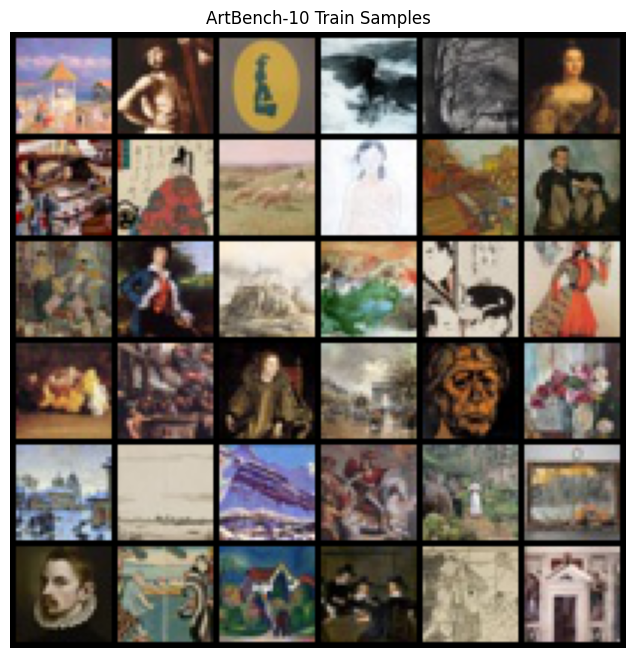

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [9]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [10]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = PROJECT_ROOT / 'exported_data' # Changed to export to Drive
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)

Exported 500 images to: c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data\train_subset\images
Metadata CSV: c:\Users\User\source\repos\genai-project1\drive_outputs\exported_data\train_subset\metadata.csv


---
# VAE
---


In [11]:
class Encoder(nn.Module):
    """Encoder maps images to latent space parameters (mu, log_var)."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.hidden_dims = list(hidden_dims)
        self.image_size = int(image_size)
        self.latent_dim = latent_dim

        # Build encoder CNN
        modules = []
        in_channels = img_channels

        for h_dim in self.hidden_dims:
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, h_dim, kernel_size=3, stride=2, padding=1),
                    nn.BatchNorm2d(h_dim),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = h_dim

        self.encoder_cnn = nn.Sequential(*modules)

        # Calculate final feature map size
        # For each stride-2 layer: size = size // 2
        self.feature_map_hw = self.image_size // (2 ** len(self.hidden_dims))

        if self.feature_map_hw < 1:
            raise ValueError(
                f"image_size={self.image_size} too small for "
                f"{len(self.hidden_dims)} downsampling layers"
            )

        final_feature_map_size = self.hidden_dims[-1] * self.feature_map_hw**2

        # Latent parameters
        self.fc_mu = nn.Linear(final_feature_map_size, latent_dim)
        self.fc_log_var = nn.Linear(final_feature_map_size, latent_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Encode image to latent parameters.

        Args:
            x: Input tensor (B, C, H, W)

        Returns:
            mu: Mean of latent distribution (B, latent_dim)
            log_var: Log variance of latent distribution (B, latent_dim)
        """
        x = self.encoder_cnn(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var


In [12]:
class Decoder(nn.Module):
    """Decoder reconstructs images from latent vectors."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.hidden_dims = list(hidden_dims)
        self.image_size = int(image_size)
        self.latent_dim = latent_dim

        # Calculate initial feature map size (same as encoder output)
        self.feature_map_hw = self.image_size // (2 ** len(self.hidden_dims))

        if self.feature_map_hw < 1:
            raise ValueError(
                f"image_size={self.image_size} too small for "
                f"{len(self.hidden_dims)} upsampling layers"
            )

        self.init_channels = self.hidden_dims[-1]

        # Project latent vector to initial feature map
        init_feature_size = self.init_channels * self.feature_map_hw**2
        self.decoder_input = nn.Linear(latent_dim, init_feature_size)

        # Build decoder CNN (reverse order of hidden dims)
        modules = []
        rev_hidden_dims = self.hidden_dims[::-1]

        # Transposed conv layers
        for i in range(len(rev_hidden_dims) - 1):
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        rev_hidden_dims[i],
                        rev_hidden_dims[i + 1],
                        kernel_size=3,
                        stride=2,
                        padding=1,
                        output_padding=1,
                    ),
                    nn.BatchNorm2d(rev_hidden_dims[i + 1]),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )

        # Final layer to output channels
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    rev_hidden_dims[-1],
                    img_channels,
                    kernel_size=3,
                    stride=2,
                    padding=1,
                    output_padding=1,
                ),
                nn.Sigmoid(),  # Output in [0, 1] range
            )
        )

        self.decoder_cnn = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """
        Decode latent vector to image.

        Args:
            z: Latent tensor (B, latent_dim)

        Returns:
            reconstruction: Reconstructed image (B, C, H, W)
        """
        x = self.decoder_input(z)
        x = x.view(-1, self.init_channels, self.feature_map_hw, self.feature_map_hw)
        x = self.decoder_cnn(x)
        return x


In [13]:
class VAE(nn.Module):
    """Variational Autoencoder combining Encoder and Decoder."""

    def __init__(
        self,
        img_channels: int = 3,
        latent_dim: int = 128,
        hidden_dims: list = None,
        image_size: int = 32,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256]

        self.latent_dim = latent_dim

        self.encoder = Encoder(
            img_channels=img_channels,
            latent_dim=latent_dim,
            hidden_dims=hidden_dims,
            image_size=image_size,
        )

        self.decoder = Decoder(
            img_channels=img_channels,
            latent_dim=latent_dim,
            hidden_dims=hidden_dims,
            image_size=image_size,
        )

    def reparameterize(
        self, mu: torch.Tensor, log_var: torch.Tensor
    ) -> torch.Tensor:
        """
        Sample latent vector using reparameterization trick.

        Args:
            mu: Mean of latent distribution (B, latent_dim)
            log_var: Log variance of latent distribution (B, latent_dim)

        Returns:
            z: Sampled latent vector (B, latent_dim)
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std, device=mu.device)
        z = mu + eps * std
        return z

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Full VAE forward pass.

        Args:
            x: Input image (B, C, H, W)

        Returns:
            reconstruction: Reconstructed image (B, C, H, W)
            mu: Latent mean (B, latent_dim)
            log_var: Latent log variance (B, latent_dim)
        """
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        reconstruction = self.decoder(z)
        return reconstruction, mu, log_var

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode image to latent parameters."""
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent vector to image."""
        return self.decoder(z)

    def sample(self, num_samples: int, device: str = "cpu") -> torch.Tensor:
        """Generate samples from standard normal distribution."""
        z = torch.randn(num_samples, self.latent_dim, device=device)
        return self.decoder(z)


In [14]:
def vae_loss(
    reconstruction: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    log_var: torch.Tensor,
    beta: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Compute VAE loss = reconstruction loss + beta * KL divergence.

    Args:
        reconstruction: Reconstructed image (B, C, H, W) in [0,1]
        x: Original image (B, C, H, W) in [0,1]
        mu: Latent mean (B, latent_dim)
        log_var: Latent log variance (B, latent_dim)
        beta: Weight for KL divergence term

    Returns:
        loss: Total VAE loss
        recon_loss: Reconstruction loss (BCE)
        kl_loss: KL divergence loss
    """
    # Reconstruction loss (Binary Cross-Entropy for [0,1] normalized images)
    recon_loss = F.binary_cross_entropy(reconstruction, x, reduction="mean")

    # KL divergence: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # Averaged over batch dimension
    kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

    # Total loss
    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss


def compute_beta_warmup(epoch: int, warmup_epochs: int, beta_max: float) -> float:
    """
    Compute KL divergence weight during warmup phase.

    Linearly increases from 0 to beta_max over warmup_epochs.

    Args:
        epoch: Current epoch (0-indexed)
        warmup_epochs: Number of warmup epochs
        beta_max: Maximum beta value

    Returns:
        beta: Current beta value
    """
    if epoch < warmup_epochs:
        return (epoch / warmup_epochs) * beta_max
    return beta_max

## Train VAE Model Baseline

Device: cuda
Train size: 10000
Batch size: 64

Starting run: vae_ldim256_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42
Epoch  1/100 | beta=0.000 | train: loss=0.6144, recon=0.6144, kl=3.0836 | 
Epoch  2/100 | beta=0.010 | train: loss=0.6007, recon=0.5954, kl=0.5316 | 
Epoch  3/100 | beta=0.020 | train: loss=0.5947, recon=0.5880, kl=0.3337 | 
Epoch  4/100 | beta=0.030 | train: loss=0.5935, recon=0.5859, kl=0.2535 | 
Epoch  5/100 | beta=0.040 | train: loss=0.5932, recon=0.5849, kl=0.2084 | 
Epoch  6/100 | beta=0.050 | train: loss=0.5931, recon=0.5841, kl=0.1796 | 
Epoch  7/100 | beta=0.060 | train: loss=0.5936, recon=0.5840, kl=0.1604 | 
Epoch  8/100 | beta=0.070 | train: loss=0.5942, recon=0.5839, kl=0.1462 | 
Epoch  9/100 | beta=0.080 | train: loss=0.5947, recon=0.5839, kl=0.1349 | 
Epoch 10/100 | beta=0.090 | train: loss=0.5958, recon=0.5844, kl=0.1260 | 
Epoch 11/100 | beta=0.100 | train: loss=0.5969, recon=0.5851, kl=0.11

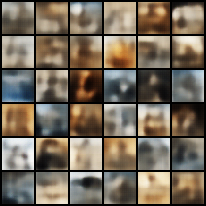

Epoch 25/100 | beta=0.100 | train: loss=0.5946, recon=0.5832, kl=0.1142 | 
Epoch 26/100 | beta=0.100 | train: loss=0.5946, recon=0.5832, kl=0.1137 | 
Epoch 27/100 | beta=0.100 | train: loss=0.5945, recon=0.5831, kl=0.1136 | 
Epoch 28/100 | beta=0.100 | train: loss=0.5944, recon=0.5830, kl=0.1140 | 
Epoch 29/100 | beta=0.100 | train: loss=0.5942, recon=0.5828, kl=0.1139 | 
Epoch 30/100 | beta=0.100 | train: loss=0.5942, recon=0.5828, kl=0.1136 | 
Epoch 31/100 | beta=0.100 | train: loss=0.5943, recon=0.5829, kl=0.1139 | 
Epoch 32/100 | beta=0.100 | train: loss=0.5941, recon=0.5827, kl=0.1139 | 
Epoch 33/100 | beta=0.100 | train: loss=0.5942, recon=0.5828, kl=0.1141 | 
Epoch 34/100 | beta=0.100 | train: loss=0.5940, recon=0.5826, kl=0.1143 | 
Epoch 35/100 | beta=0.100 | train: loss=0.5938, recon=0.5824, kl=0.1140 | 
Epoch 36/100 | beta=0.100 | train: loss=0.5938, recon=0.5823, kl=0.1142 | 
Epoch 37/100 | beta=0.100 | train: loss=0.5936, recon=0.5822, kl=0.1139 | 
Epoch 38/100 | beta=0.100

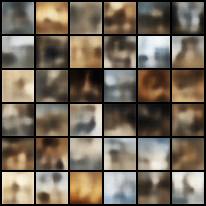

Epoch 50/100 | beta=0.100 | train: loss=0.5934, recon=0.5820, kl=0.1146 | 
Epoch 51/100 | beta=0.100 | train: loss=0.5934, recon=0.5820, kl=0.1142 | 
Epoch 52/100 | beta=0.100 | train: loss=0.5934, recon=0.5819, kl=0.1144 | 
Epoch 53/100 | beta=0.100 | train: loss=0.5930, recon=0.5816, kl=0.1142 | 
Epoch 54/100 | beta=0.100 | train: loss=0.5930, recon=0.5816, kl=0.1141 | 
Epoch 55/100 | beta=0.100 | train: loss=0.5931, recon=0.5817, kl=0.1142 | 
Epoch 56/100 | beta=0.100 | train: loss=0.5931, recon=0.5816, kl=0.1143 | 
Epoch 57/100 | beta=0.100 | train: loss=0.5931, recon=0.5816, kl=0.1145 | 
Epoch 58/100 | beta=0.100 | train: loss=0.5931, recon=0.5817, kl=0.1144 | 
Epoch 59/100 | beta=0.100 | train: loss=0.5930, recon=0.5815, kl=0.1144 | 
Epoch 60/100 | beta=0.100 | train: loss=0.5929, recon=0.5815, kl=0.1143 | 
Epoch 61/100 | beta=0.100 | train: loss=0.5930, recon=0.5815, kl=0.1142 | 
Epoch 62/100 | beta=0.100 | train: loss=0.5928, recon=0.5814, kl=0.1140 | 
Epoch 63/100 | beta=0.100

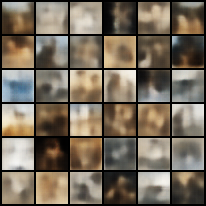

Epoch 75/100 | beta=0.100 | train: loss=0.5924, recon=0.5809, kl=0.1149 | 
Epoch 76/100 | beta=0.100 | train: loss=0.5925, recon=0.5810, kl=0.1144 | 
Epoch 77/100 | beta=0.100 | train: loss=0.5923, recon=0.5808, kl=0.1147 | 
Epoch 78/100 | beta=0.100 | train: loss=0.5923, recon=0.5808, kl=0.1147 | 
Epoch 79/100 | beta=0.100 | train: loss=0.5924, recon=0.5809, kl=0.1147 | 
Epoch 80/100 | beta=0.100 | train: loss=0.5922, recon=0.5807, kl=0.1148 | 
Epoch 81/100 | beta=0.100 | train: loss=0.5922, recon=0.5808, kl=0.1146 | 
Epoch 82/100 | beta=0.100 | train: loss=0.5923, recon=0.5808, kl=0.1149 | 
Epoch 83/100 | beta=0.100 | train: loss=0.5924, recon=0.5810, kl=0.1148 | 
Epoch 84/100 | beta=0.100 | train: loss=0.5921, recon=0.5807, kl=0.1146 | 
Epoch 85/100 | beta=0.100 | train: loss=0.5923, recon=0.5808, kl=0.1151 | 
Epoch 86/100 | beta=0.100 | train: loss=0.5923, recon=0.5808, kl=0.1149 | 
Epoch 87/100 | beta=0.100 | train: loss=0.5923, recon=0.5808, kl=0.1145 | 
Epoch 88/100 | beta=0.100

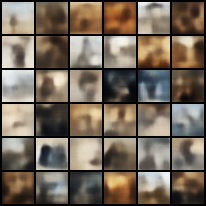

Epoch 100/100 | beta=0.100 | train: loss=0.5921, recon=0.5806, kl=0.1149 | 
----------------------------------------------------------------------------------------------------
Finished vae_ldim256_ep100_seed42 | best_train_loss=0.5918 | best_epoch=98 | time=9.2 min
----------------------------------------------------------------------------------------------------

VAE TRAINING FINISHED
latent_dim=256 | best_train_loss=0.5918 | best_epoch=98 | dir=c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42

Summary CSV saved to: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\summary_vae.csv


In [15]:
import os
import csv
import json
import gc
import time
from pathlib import Path

import torch
import torch.optim as optim
from torchvision.utils import save_image
from IPython.display import display as ipy_display, Image as IPyImage

# =========================
# Config
# =========================
latent_dim = 256

img_channels = 3
image_size = IMAGE_SIZE
hidden_dims = [32, 64, 128, 256]

learning_rate = 1e-3
weight_decay = 0.0
num_epochs = 100

beta_max = 0.1
warmup_epochs = 10

seed = 42
model_family = "vae"

# =========================
# Paths
# =========================
base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = base_runs_dir / "summary_vae.csv"

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 100)
print(f"Device: {device}")
print(f"Train size: {len(train_loader_from_csv.dataset)}")
print(f"Batch size: {train_loader_from_csv.batch_size}")
print("=" * 100)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def train_vae_for_latent_dim(latent_dim: int):
    run_name = f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_csv_path = run_dir / "metrics.csv"
    config_json_path = run_dir / "config.json"
    best_ckpt_path = run_dir / "best_model.pt"
    final_ckpt_path = run_dir / "final_model.pt"
    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "run_name": run_name,
        "model_family": model_family,
        "seed": seed,
        "img_channels": img_channels,
        "image_size": image_size,
        "latent_dim": latent_dim,
        "hidden_dims": hidden_dims,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "num_epochs": num_epochs,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
    }
    save_json(config, config_json_path)

    vae_model = VAE(
        img_channels=img_channels,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        image_size=image_size,
    ).to(device)

    optimizer = optim.Adam(
        vae_model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

    fieldnames = [
        "epoch",
        "beta",
        "train_loss",
        "train_recon",
        "train_kl",
    ]

    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

    best_train_loss = float("inf")
    best_epoch = -1

    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        beta = compute_beta_warmup(epoch, warmup_epochs, beta_max)

        # ---- TRAIN ----
        vae_model.train()
        train_loss_sum = 0.0
        train_recon_sum = 0.0
        train_kl_sum = 0.0
        train_num_batches = 0

        for batch in train_loader_from_csv:
            x = batch[0].to(device, non_blocking=True)

            optimizer.zero_grad()

            reconstruction, mu, log_var = vae_model(x)
            loss, recon_loss, kl_loss = vae_loss(
                reconstruction, x, mu, log_var, beta=beta
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_sum += loss.item()
            train_recon_sum += recon_loss.item()
            train_kl_sum += kl_loss.item()
            train_num_batches += 1

        train_loss = train_loss_sum / train_num_batches
        train_recon = train_recon_sum / train_num_batches
        train_kl = train_kl_sum / train_num_batches

        scheduler.step()

        row = {
            "epoch": epoch + 1,
            "beta": beta,
            "train_loss": train_loss,
            "train_recon": train_recon,
            "train_kl": train_kl,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # ---- Save best ----
        if (epoch + 1) > warmup_epochs and train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch = epoch + 1

            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": vae_model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_train_loss": best_train_loss,
                    "config": config,
                },
                best_ckpt_path,
            )

        if (epoch + 1) % 25 == 0:
            with torch.no_grad():
                z = torch.randn(36, latent_dim, device=device)
                samples = vae_model.decode(z).clamp(0.0, 1.0)
            _sp = samples_dir / f"samples_epoch_{epoch+1:03d}.png"
            save_image(samples, _sp, nrow=6)
            print(f"VAE samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(_sp), width=500))

        print(
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"beta={beta:.3f} | "
            f"train: loss={train_loss:.4f}, recon={train_recon:.4f}, kl={train_kl:.4f} | "

        )

    total_time_sec = time.time() - start_time

    # ---- Save final checkpoint ----
    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": vae_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_train_loss": best_train_loss,
            "best_epoch": best_epoch,
            "config": config,
        },
        final_ckpt_path,
    )

    summary_row = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": str(run_dir),
        "best_ckpt_path": str(best_ckpt_path),
        "final_ckpt_path": str(final_ckpt_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"best_train_loss={best_train_loss:.4f} | "
        f"best_epoch={best_epoch} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "latent_dim",
    "num_epochs",
    "best_epoch",
    "best_train_loss",
    "train_size",
    "batch_size",
    "beta_max",
    "warmup_epochs",
    "learning_rate",
    "weight_decay",
    "run_dir",
    "best_ckpt_path",
    "final_ckpt_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

try:
    result = train_vae_for_latent_dim(latent_dim)

except RuntimeError as e:
    result = {
        "run_name": f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}",
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "best_epoch": None,
        "best_train_loss": None,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "beta_max": beta_max,
        "warmup_epochs": warmup_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": "",
        "best_ckpt_path": "",
        "final_ckpt_path": "",
        "time_sec": None,
        "status": f"runtime_error: {str(e)}",
    }
    print("\n" + "!" * 100)
    print(f"Run failed for latent_dim={latent_dim}")
    print(str(e))
    print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["best_train_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: x["best_train_loss"])

print("\n" + "=" * 100)
print("VAE TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"latent_dim={r['latent_dim']} | best_train_loss={r['best_train_loss']:.4f} | best_epoch={r['best_epoch']} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

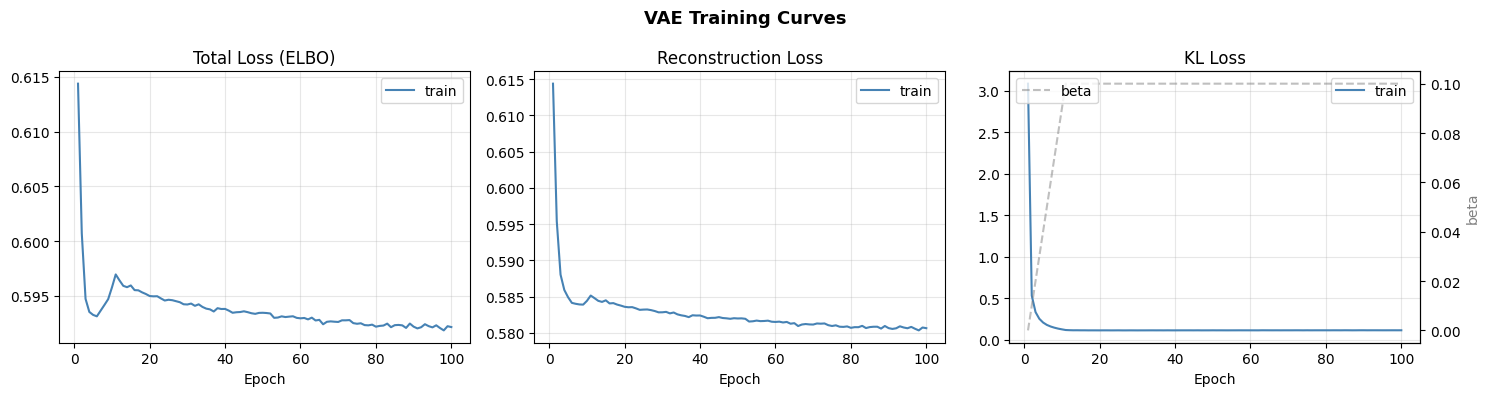

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\vae_training_curves.png


In [16]:
# VAE — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "vae_ldim256_ep100_seed42" / "metrics.csv"
_fig_dir = _runs / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)

if _metrics.exists():
    ep, tr_loss, tr_recon, tr_kl, betas = [], [], [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            tr_loss.append(float(row["train_loss"]))
            tr_recon.append(float(row["train_recon"]))
            tr_kl.append(float(row["train_kl"]))
            betas.append(float(row["beta"]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, tr, title in zip(axes,
        [tr_loss, tr_recon, tr_kl],
        ["Total Loss (ELBO)", "Reconstruction Loss", "KL Loss"]):
        ax.plot(ep, tr, label="train", color="steelblue")
        ax.set_title(title); ax.set_xlabel("Epoch")
        ax.legend(); ax.grid(True, alpha=0.3)

    ax2 = axes[2].twinx()
    ax2.plot(ep, betas, color="gray", linestyle="--", alpha=0.5, label="beta")
    ax2.set_ylabel("beta", color="gray"); ax2.legend(loc="upper left")

    fig.suptitle("VAE Training Curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(_fig_dir / "vae_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'vae_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


Lessons Learned so far:
- Trained with latend_dim = 32, 64, 128, 256, 512, 1024
- Greater the latent_dim => better results only to a certain point


## Sample from VAE

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42
Loaded epoch: 98 | best_train_loss: 0.5918


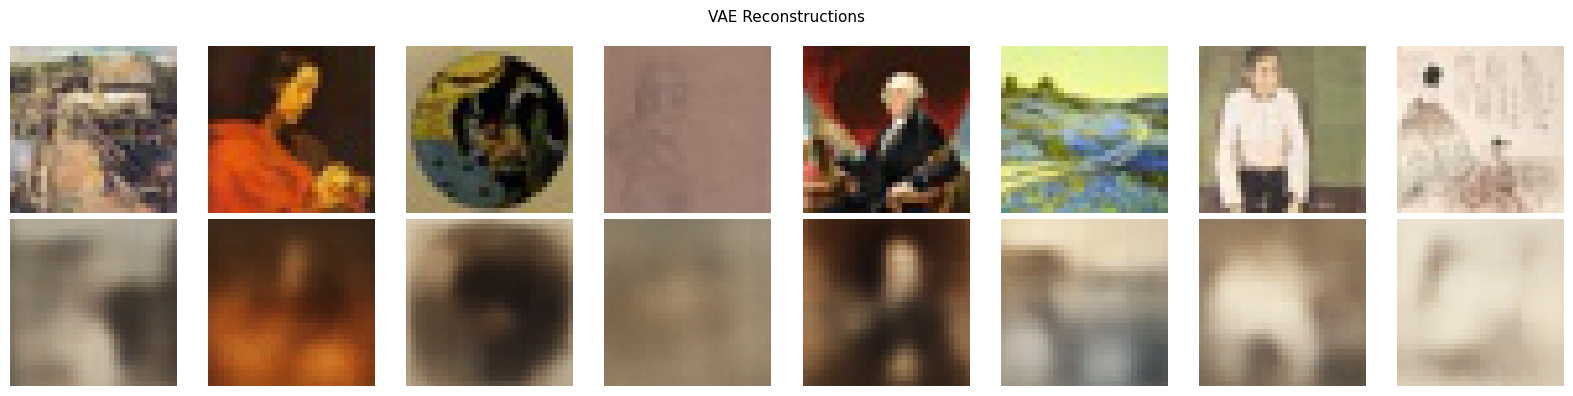

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\vae_reconstructions.png
Inference time (36 samples): 0.002s  |  0.1 ms/image


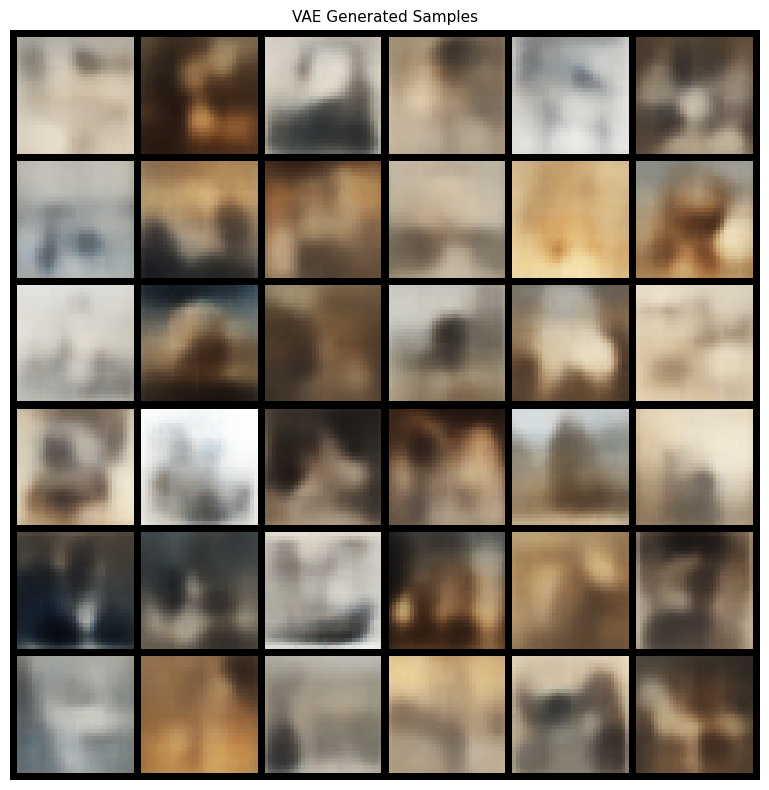

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\vae_samples.png


In [17]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
_fig_dir = base_runs_dir / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256
num_epochs = 100
seed = 42


def save_image_grid(images, save_path, n_images=36, nrow=6, title=""):
    images = images[:n_images].detach().cpu().clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np_img); ax.axis("off")
    if title: ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def save_reconstructions(model, x, save_path, title="", n_show=8):
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(x)
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4))
    for i in range(n_show):
        axes[0, i].imshow(x[i].detach().cpu().permute(1, 2, 0).numpy())
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy())
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=9)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=9)
    if title: fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


x_batch, _, _ = next(iter(train_loader_from_csv))
x_batch = x_batch[:8].to(device)

run_name = f"vae_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
run_dir = base_runs_dir / run_name
best_ckpt_path = run_dir / "best_model.pt"
print(f"Run dir: {run_dir}")

if not best_ckpt_path.exists():
    print(f"Checkpoint not found: {best_ckpt_path}")
else:
    vae_model = VAE(
        img_channels=3, latent_dim=latent_dim,
        hidden_dims=[32, 64, 128, 256], image_size=IMAGE_SIZE,
    ).to(device)

    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    vae_model.load_state_dict(checkpoint["model_state_dict"])
    vae_model.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | best_train_loss: {checkpoint.get('best_train_loss', checkpoint.get('best_val_loss', '?')):.4f}")

    save_reconstructions(vae_model, x_batch,
        save_path=_fig_dir / "vae_reconstructions.png",
        title="VAE Reconstructions")

    import time as _time_mod
    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():  # GPU warmup
        _ = vae_model.sample(4, device=device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        samples = vae_model.sample(36, device=device)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference time (36 samples): {_infer_time:.3f}s  |  {_infer_time/36*1000:.1f} ms/image")
    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["vae"] = {"time_36_samples_sec": round(_infer_time, 4), "ms_per_image": round(_infer_time/36*1000, 2)}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    save_image_grid(samples, save_path=_fig_dir / "vae_samples.png",
        n_images=36, nrow=6, title="VAE Generated Samples")


---
# DCGAN
---

In [18]:
import torch
import torch.nn as nn


class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = 128,
        img_channels: int = 3,
        img_size: int = 32,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.img_size = img_size
        self.img_channels = img_channels
        self.hidden_dims = hidden_dims

        # For img_size=32 and 4 upsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2 (encoder view)
        # so generator starts from 2x2 and upsamples back to 32x32
        self.initial_spatial_dim = img_size // (2 ** len(hidden_dims))
        if self.initial_spatial_dim < 1:
            raise ValueError(
                f"img_size={img_size} too small for {len(hidden_dims)} upsampling layers"
            )

        self.initial_channels = hidden_dims[-1]

        # Project z -> initial feature map
        self.initial_projection = nn.Linear(
            latent_dim,
            self.initial_channels * (self.initial_spatial_dim ** 2)
        )

        modules = []
        reversed_hidden_dims = hidden_dims[::-1]  # e.g. [256, 128, 64, 32]

        in_channels = reversed_hidden_dims[0]
        for i in range(len(reversed_hidden_dims) - 1):
            out_channels = reversed_hidden_dims[i + 1]
            modules.append(
                nn.Sequential(
                    nn.ConvTranspose2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(True),
                )
            )
            in_channels = out_channels

        # Final upsampling to image
        modules.append(
            nn.Sequential(
                nn.ConvTranspose2d(
                    in_channels,
                    img_channels,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.Tanh(),  # output in [-1, 1]
            )
        )

        self.main = nn.Sequential(*modules)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.initial_projection(z)
        x = x.view(
            -1,
            self.initial_channels,
            self.initial_spatial_dim,
            self.initial_spatial_dim,
        )
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] = [32, 64, 128, 256],
    ):
        super().__init__()

        modules = []

        # First block: no BatchNorm (standard DCGAN practice)
        modules.append(
            nn.Sequential(
                nn.Conv2d(
                    img_channels,
                    hidden_dims[0],
                    kernel_size=4,
                    stride=2,
                    padding=1,
                    bias=False,
                ),
                nn.LeakyReLU(0.2, inplace=True),
            )
        )

        in_channels = hidden_dims[0]

        for i in range(1, len(hidden_dims)):
            out_channels = hidden_dims[i]
            modules.append(
                nn.Sequential(
                    nn.Conv2d(
                        in_channels,
                        out_channels,
                        kernel_size=4,
                        stride=2,
                        padding=1,
                        bias=False,
                    ),
                    nn.BatchNorm2d(out_channels),
                    nn.LeakyReLU(0.2, inplace=True),
                )
            )
            in_channels = out_channels

        self.main = nn.Sequential(*modules)

        # For 32x32 with 4 downsampling blocks:
        # 32 -> 16 -> 8 -> 4 -> 2
        # final 2x2 -> 1x1 scalar
        self.final_conv = nn.Conv2d(
            in_channels,
            1,
            kernel_size=2,
            stride=1,
            padding=0,
            bias=False,
        )

    def forward(self, img: torch.Tensor) -> torch.Tensor:
        x = self.main(img)
        x = self.final_conv(x)
        return x.view(-1)  # raw logits


def dcgan_weights_init(m):
    """
    DCGAN-style weight initialization.
    """
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

## Train DCGAN Model

train_loader_gan not found. Rebuilding now...
Device: cuda
Train size: 10000
Batch size: 64

Starting run: dcgan_ldim256_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42
Epoch  1/100 | D_loss=0.4041 | G_loss=4.8764 | D(real)=0.8643 | D(fake)=0.0502
Epoch  2/100 | D_loss=0.8374 | G_loss=2.9647 | D(real)=0.7289 | D(fake)=0.1216
Epoch  3/100 | D_loss=0.6257 | G_loss=3.5161 | D(real)=0.7725 | D(fake)=0.0607
Epoch  4/100 | D_loss=0.5385 | G_loss=3.9045 | D(real)=0.8185 | D(fake)=0.0465
Epoch  5/100 | D_loss=0.7307 | G_loss=3.3149 | D(real)=0.7444 | D(fake)=0.0716
Epoch  6/100 | D_loss=0.7571 | G_loss=3.1561 | D(real)=0.7329 | D(fake)=0.0809
Epoch  7/100 | D_loss=0.8323 | G_loss=3.0493 | D(real)=0.7337 | D(fake)=0.0954
Epoch  8/100 | D_loss=0.7624 | G_loss=3.2937 | D(real)=0.7561 | D(fake)=0.0836
Epoch  9/100 | D_loss=0.8381 | G_loss=3.3730 | D(real)=0.7236 | D(fake)=0.0814
Epoch 10/100 | D_loss=0.8740 | G_loss=3.1451 | D(real)=0.7

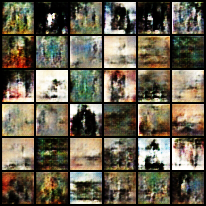

Epoch 25/100 | D_loss=0.8046 | G_loss=4.0441 | D(real)=0.7967 | D(fake)=0.1104
Epoch 26/100 | D_loss=0.7492 | G_loss=4.1354 | D(real)=0.8083 | D(fake)=0.1015
Epoch 27/100 | D_loss=0.7226 | G_loss=4.2689 | D(real)=0.8337 | D(fake)=0.0958
Epoch 28/100 | D_loss=0.8184 | G_loss=4.3530 | D(real)=0.8287 | D(fake)=0.1173
Epoch 29/100 | D_loss=0.8958 | G_loss=4.2762 | D(real)=0.8317 | D(fake)=0.1281
Epoch 30/100 | D_loss=0.7576 | G_loss=5.2301 | D(real)=0.8359 | D(fake)=0.0751
Epoch 31/100 | D_loss=1.1011 | G_loss=4.7976 | D(real)=0.7901 | D(fake)=0.1333
Epoch 32/100 | D_loss=0.9504 | G_loss=4.4391 | D(real)=0.7968 | D(fake)=0.1190
Epoch 33/100 | D_loss=0.8018 | G_loss=4.7803 | D(real)=0.8124 | D(fake)=0.1016
Epoch 34/100 | D_loss=0.8366 | G_loss=5.2753 | D(real)=0.8004 | D(fake)=0.0909
Epoch 35/100 | D_loss=0.8793 | G_loss=5.3920 | D(real)=0.8339 | D(fake)=0.0932
Epoch 36/100 | D_loss=0.9528 | G_loss=5.2458 | D(real)=0.8170 | D(fake)=0.1052
Epoch 37/100 | D_loss=1.0122 | G_loss=5.2806 | D(rea

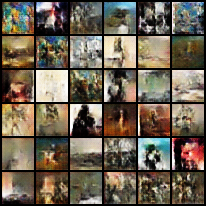

Epoch 50/100 | D_loss=0.7616 | G_loss=6.7885 | D(real)=0.8602 | D(fake)=0.0828
Epoch 51/100 | D_loss=0.6510 | G_loss=6.9738 | D(real)=0.9110 | D(fake)=0.0814
Epoch 52/100 | D_loss=0.7030 | G_loss=7.1365 | D(real)=0.8650 | D(fake)=0.0625
Epoch 53/100 | D_loss=0.7059 | G_loss=7.4396 | D(real)=0.8638 | D(fake)=0.0598
Epoch 54/100 | D_loss=0.8040 | G_loss=7.1563 | D(real)=0.8593 | D(fake)=0.0902
Epoch 55/100 | D_loss=0.7092 | G_loss=8.1717 | D(real)=0.8773 | D(fake)=0.0760
Epoch 56/100 | D_loss=0.7658 | G_loss=8.1230 | D(real)=0.8493 | D(fake)=0.0659
Epoch 57/100 | D_loss=0.6522 | G_loss=8.4321 | D(real)=0.8882 | D(fake)=0.0655
Epoch 58/100 | D_loss=0.8270 | G_loss=7.6894 | D(real)=0.8815 | D(fake)=0.0928
Epoch 59/100 | D_loss=0.6876 | G_loss=8.7531 | D(real)=0.8608 | D(fake)=0.0562
Epoch 60/100 | D_loss=0.8027 | G_loss=8.3110 | D(real)=0.8631 | D(fake)=0.0782
Epoch 61/100 | D_loss=0.8780 | G_loss=8.2205 | D(real)=0.8705 | D(fake)=0.0762
Epoch 62/100 | D_loss=0.7759 | G_loss=8.8376 | D(rea

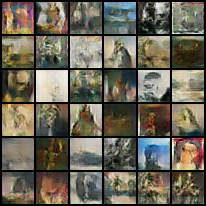

Epoch 75/100 | D_loss=0.6548 | G_loss=9.6118 | D(real)=0.8966 | D(fake)=0.0689
Epoch 76/100 | D_loss=0.5661 | G_loss=10.4191 | D(real)=0.8923 | D(fake)=0.0425
Epoch 77/100 | D_loss=1.0023 | G_loss=9.9651 | D(real)=0.8874 | D(fake)=0.0915
Epoch 78/100 | D_loss=0.8934 | G_loss=9.9765 | D(real)=0.9190 | D(fake)=0.0954
Epoch 79/100 | D_loss=0.5770 | G_loss=10.7898 | D(real)=0.9027 | D(fake)=0.0386
Epoch 80/100 | D_loss=0.9126 | G_loss=10.3331 | D(real)=0.8957 | D(fake)=0.0627
Epoch 81/100 | D_loss=1.1245 | G_loss=9.7336 | D(real)=0.8912 | D(fake)=0.0982
Epoch 82/100 | D_loss=1.0333 | G_loss=10.3195 | D(real)=0.9100 | D(fake)=0.0840
Epoch 83/100 | D_loss=0.7817 | G_loss=10.4058 | D(real)=0.8811 | D(fake)=0.0566
Epoch 84/100 | D_loss=0.7950 | G_loss=10.5326 | D(real)=0.9049 | D(fake)=0.0684
Epoch 85/100 | D_loss=0.8221 | G_loss=11.4991 | D(real)=0.8980 | D(fake)=0.0500
Epoch 86/100 | D_loss=0.5612 | G_loss=11.2024 | D(real)=0.9089 | D(fake)=0.0452
Epoch 87/100 | D_loss=0.7744 | G_loss=11.459

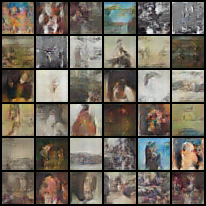

Epoch 100/100 | D_loss=0.7117 | G_loss=12.9327 | D(real)=0.9044 | D(fake)=0.0463
----------------------------------------------------------------------------------------------------
Finished dcgan_ldim256_ep100_seed42 | time=10.0 min
----------------------------------------------------------------------------------------------------

DCGAN TRAINING FINISHED
latent_dim=256 | final_g_loss=12.9327 | dir=c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42

Summary CSV saved to: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\summary_dcgan.csv


In [19]:
import os
import csv
import json
import gc
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid
from IPython.display import display as ipy_display, Image as IPyImage

# =========================
# Config
# =========================
latent_dim = 256

img_channels = 3
img_size = IMAGE_SIZE
hidden_dims = [32, 64, 128, 256]

learning_rate = 2e-4
beta1 = 0.5
beta2 = 0.999
num_epochs = 100

seed = 42
model_family = "dcgan"

# =========================
# Paths
# =========================
base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = base_runs_dir / "summary_dcgan.csv"

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Ensure GAN dataloader exists
# =========================
if "train_loader_gan" not in globals():
    print("train_loader_gan not found. Rebuilding now...")

    transform_gan = T.Compose([
        T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
        T.CenterCrop(IMAGE_SIZE),
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # [0,1] -> [-1,1]
    ])

    train_ds_gan = HFDatasetTorch(train_hf, transform=transform_gan, indices=train_ids_from_csv)
    train_loader_gan = DataLoader(
        train_ds_gan,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=EFFECTIVE_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

print("=" * 100)
print(f"Device: {device}")
print(f"Train size: {len(train_loader_gan.dataset)}")
print(f"Batch size: {train_loader_gan.batch_size}")
print("=" * 100)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)


def save_sample_grid(generator, noise, save_path, nrow=6):
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
    fake = (fake + 1.0) / 2.0  # [-1,1] -> [0,1]
    fake = fake.clamp(0, 1)
    grid = make_grid(fake, nrow=nrow, padding=2)
    save_image(grid, save_path)
    generator.train()


def train_dcgan_for_latent_dim(latent_dim: int):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    run_name = f"dcgan_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    metrics_csv_path = run_dir / "metrics.csv"
    config_json_path = run_dir / "config.json"
    final_g_path = run_dir / "final_generator.pt"
    final_d_path = run_dir / "final_discriminator.pt"
    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir = run_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    config = {
        "run_name": run_name,
        "model_family": model_family,
        "seed": seed,
        "latent_dim": latent_dim,
        "img_channels": img_channels,
        "img_size": img_size,
        "hidden_dims": hidden_dims,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "num_epochs": num_epochs,
        "train_size": len(train_loader_gan.dataset),
        "batch_size": train_loader_gan.batch_size,
    }
    save_json(config, config_json_path)

    G = Generator(
        latent_dim=latent_dim,
        img_channels=img_channels,
        img_size=img_size,
        hidden_dims=hidden_dims,
    ).to(device)

    D = Discriminator(
        img_channels=img_channels,
        hidden_dims=hidden_dims,
    ).to(device)

    G.apply(dcgan_weights_init)
    D.apply(dcgan_weights_init)

    criterion = nn.BCEWithLogitsLoss()

    optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(beta1, beta2))
    optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(beta1, beta2))

    fixed_noise = torch.randn(36, latent_dim, device=device)

    fieldnames = [
        "epoch",
        "d_loss",
        "g_loss",
        "d_real_mean",
        "d_fake_mean",
    ]

    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()



    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        G.train()
        D.train()

        d_loss_sum = 0.0
        g_loss_sum = 0.0
        d_real_mean_sum = 0.0
        d_fake_mean_sum = 0.0
        num_batches = 0

        for batch in train_loader_gan:
            real_imgs = batch[0].to(device, non_blocking=True)
            batch_size = real_imgs.size(0)

            real_labels = torch.ones(batch_size, device=device)
            fake_labels = torch.zeros(batch_size, device=device)

            # -----------------
            # Train D
            # -----------------
            optimizer_D.zero_grad()

            real_logits = D(real_imgs)
            d_loss_real = criterion(real_logits, real_labels)

            z = torch.randn(batch_size, latent_dim, device=device)
            fake_imgs = G(z)

            fake_logits = D(fake_imgs.detach())
            d_loss_fake = criterion(fake_logits, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
            optimizer_D.step()

            # -----------------
            # Train G
            # -----------------
            optimizer_G.zero_grad()

            fake_logits_for_g = D(fake_imgs)  # reuse same fake_imgs from D step

            g_loss = criterion(fake_logits_for_g, real_labels)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()

            d_loss_sum += d_loss.item()
            g_loss_sum += g_loss.item()
            d_real_mean_sum += torch.sigmoid(real_logits).mean().item()
            d_fake_mean_sum += torch.sigmoid(fake_logits_for_g).mean().item()
            num_batches += 1

        d_loss_epoch = d_loss_sum / num_batches
        g_loss_epoch = g_loss_sum / num_batches
        d_real_mean_epoch = d_real_mean_sum / num_batches
        d_fake_mean_epoch = d_fake_mean_sum / num_batches

        row = {
            "epoch": epoch + 1,
            "d_loss": d_loss_epoch,
            "g_loss": g_loss_epoch,
            "d_real_mean": d_real_mean_epoch,
            "d_fake_mean": d_fake_mean_epoch,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            periodic_path = ckpt_dir / f"checkpoint_epoch_{epoch+1:03d}.pt"
            torch.save(
                {
                    "epoch": epoch + 1,
                    "generator_state_dict": G.state_dict(),
                    "discriminator_state_dict": D.state_dict(),
                    "config": config,
                },
                periodic_path,
            )

        if (epoch + 1) % 25 == 0:
            sample_path = samples_dir / f"epoch_{epoch+1:03d}.png"
            save_sample_grid(G, fixed_noise, sample_path)
            print(f"DCGAN samples — epoch {epoch+1}")
            ipy_display(IPyImage(str(sample_path), width=500))

        print(
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"D_loss={d_loss_epoch:.4f} | "
            f"G_loss={g_loss_epoch:.4f} | "
            f"D(real)={d_real_mean_epoch:.4f} | "
            f"D(fake)={d_fake_mean_epoch:.4f}"
        )

    total_time_sec = time.time() - start_time

    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": G.state_dict(),
            "optimizer_state_dict": optimizer_G.state_dict(),
            "final_g_loss": g_loss_epoch,
            "config": config,
        },
        final_g_path,
    )

    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": D.state_dict(),
            "optimizer_state_dict": optimizer_D.state_dict(),
            "config": config,
        },
        final_d_path,
    )

    summary_row = {
        "run_name": run_name,
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "final_g_loss": g_loss_epoch,
        "train_size": len(train_loader_gan.dataset),
        "batch_size": train_loader_gan.batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "run_dir": str(run_dir),
        "final_g_path": str(final_g_path),
        "final_d_path": str(final_d_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "latent_dim",
    "num_epochs",
    "final_g_loss",
    "train_size",
    "batch_size",
    "learning_rate",
    "beta1",
    "beta2",
    "run_dir",
    "final_g_path",
    "final_d_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

try:
    result = train_dcgan_for_latent_dim(latent_dim)

except RuntimeError as e:
    result = {
        "run_name": f"dcgan_ldim{latent_dim}_ep{num_epochs}_seed{seed}",
        "latent_dim": latent_dim,
        "num_epochs": num_epochs,
        "final_g_loss": None,
        "train_size": len(train_loader_gan.dataset),
        "batch_size": train_loader_gan.batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "run_dir": "",
        "final_g_path": "",
        "final_d_path": "",
        "time_sec": None,
        "status": f"runtime_error: {str(e)}",
    }
    print("\n" + "!" * 100)
    print(f"Run failed for latent_dim={latent_dim}")
    print(str(e))
    print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["final_g_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: (x["final_g_loss"] or float('inf')))

print("\n" + "=" * 100)
print("DCGAN TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"latent_dim={r['latent_dim']} | final_g_loss={r['final_g_loss']:.4f} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

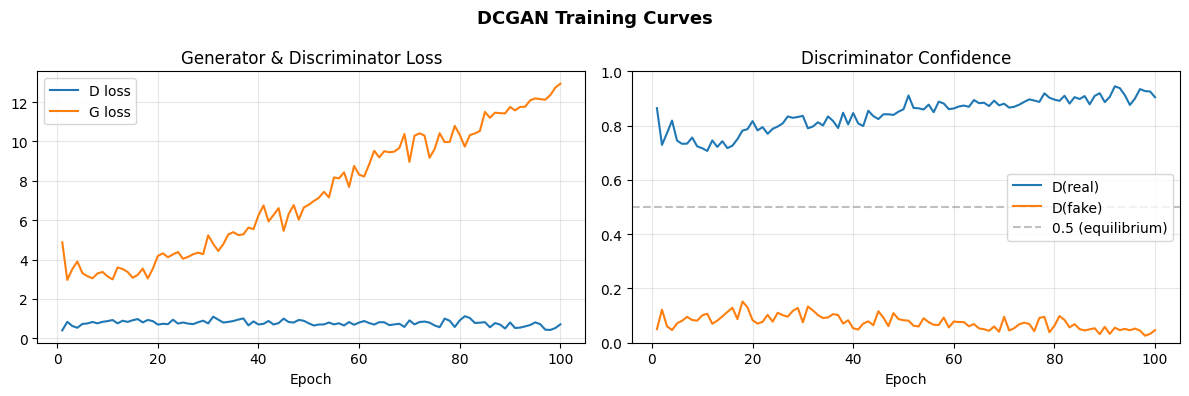

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\gan_training_curves.png


In [20]:
# GAN — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "dcgan_ldim256_ep100_seed42" / "metrics.csv"

if _metrics.exists():
    ep, d_loss, g_loss, d_real, d_fake = [], [], [], [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            d_loss.append(float(row["d_loss"]));     g_loss.append(float(row["g_loss"]))
            d_real.append(float(row["d_real_mean"])); d_fake.append(float(row["d_fake_mean"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(ep, d_loss, label="D loss")
    axes[0].plot(ep, g_loss, label="G loss")
    axes[0].set_title("Generator & Discriminator Loss")
    axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ep, d_real, label="D(real)")
    axes[1].plot(ep, d_fake, label="D(fake)")
    axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5 (equilibrium)")
    axes[1].set_title("Discriminator Confidence")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylim(0, 1)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.suptitle("DCGAN Training Curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    _fig_dir = (_runs / "figures")
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "gan_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'gan_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


## Sample from DCGAN

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42
Loaded epoch: 100 | Final G loss: 12.9327
Inference time (36 samples): 0.001s  |  0.0 ms/image
Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\gan_samples.png


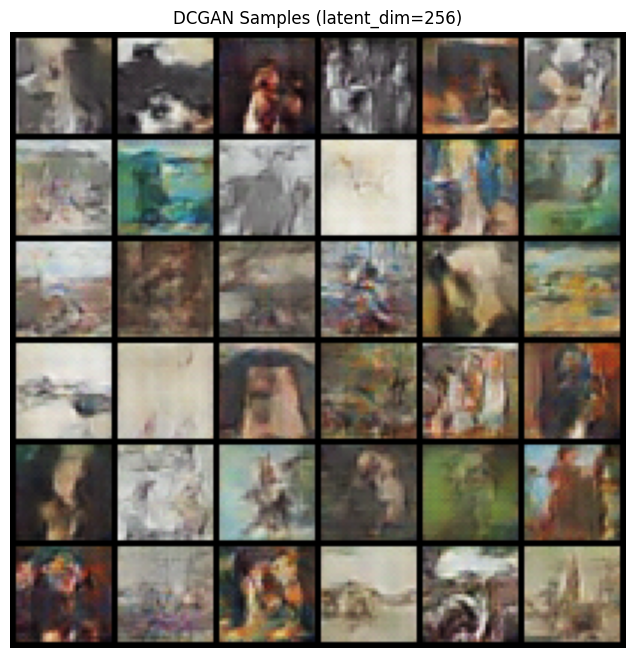

In [21]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256
num_epochs = 100
seed = 42

def show_image_grid(images, n_images=36, nrow=6, title="Image Grid"):
    images = images[:n_images].detach().cpu()
    images = (images + 1.0) / 2.0  # GAN outputs [-1, 1]
    images = images.clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis("off")
    plt.title(title)
    _fig_dir = base_runs_dir / "figures"
    _fig_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(_fig_dir / "gan_samples.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {_fig_dir / 'gan_samples.png'}")
    plt.show()


torch.manual_seed(seed)

run_name = f"dcgan_ldim{latent_dim}_ep{num_epochs}_seed{seed}"
run_dir = base_runs_dir / run_name
ckpt_path = run_dir / "final_generator.pt"

print(f"Run dir: {run_dir}")

if not ckpt_path.exists():
    print(f"Checkpoint not found: {ckpt_path}")
else:
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = checkpoint["config"]

    G = Generator(
        latent_dim=cfg["latent_dim"],
        img_channels=cfg["img_channels"],
        img_size=cfg["img_size"],
        hidden_dims=cfg["hidden_dims"],
    ).to(device)

    G.load_state_dict(checkpoint["model_state_dict"])
    G.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | Final G loss: {checkpoint['final_g_loss']:.4f}")

    import time as _time_mod
    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():  # GPU warmup
        _ = G(torch.randn(4, cfg["latent_dim"], device=device))
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        z = torch.randn(36, cfg["latent_dim"], device=device)
        samples = G(z)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference time (36 samples): {_infer_time:.3f}s  |  {_infer_time/36*1000:.1f} ms/image")
    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["dcgan"] = {"time_36_samples_sec": round(_infer_time, 4), "ms_per_image": round(_infer_time/36*1000, 2)}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    show_image_grid(samples, n_images=36, nrow=6, title=f"DCGAN Samples (latent_dim={latent_dim})")


---
# Diffusion Model

---




In [22]:
"""Diffusion Model for ArtBench-10."""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


def sinusoidal_embeddings(n_steps: int, dim: int) -> torch.Tensor:
    """Fixed sinusoidal embeddings table (interleaved sin/cos), shape (n_steps, dim)."""
    emb = torch.zeros(n_steps, dim)
    position = torch.arange(0, n_steps).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2) * (-math.log(10000.0) / dim))
    emb[:, 0::2] = torch.sin(position * div_term)
    emb[:, 1::2] = torch.cos(position * div_term)
    return emb


def _get_groups(channels: int, num_groups: int = 8) -> int:
    """Find largest divisor of channels that is <= num_groups."""
    g = max(1, min(num_groups, channels))
    while channels % g != 0:
        g -= 1
    return g


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""

    def __init__(self, in_channels: int, out_channels: int, time_emb_dim: int, num_groups: int = 8, dropout: float = 0.0):
        super().__init__()

        self.norm1 = nn.GroupNorm(_get_groups(in_channels, num_groups), in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        self.time_emb_proj = nn.Linear(time_emb_dim, out_channels)

        self.norm2 = nn.GroupNorm(_get_groups(out_channels, num_groups), out_channels)
        self.act2 = nn.SiLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act1(self.norm1(x)))
        h = h + self.time_emb_proj(time_emb)[:, :, None, None]
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.skip(x)


class DownBlock(nn.Module):
    """Two ResBlocks (maintain channels) + strided conv that changes channels."""

    def __init__(self, channels: int, next_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.res1 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(channels, channels, time_emb_dim, dropout=dropout)
        self.down = nn.Conv2d(channels, next_channels, kernel_size=4, stride=2, padding=1)

    def forward(self, x: torch.Tensor, time_emb: torch.Tensor):
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        skip = x          # saved before downsampling, at original channels
        x = self.down(x)  # spatial downsample + channel change
        return x, skip


class UpBlock(nn.Module):
    """Transposed conv + concat skip + two ResBlocks."""

    def __init__(self, in_channels: int, out_channels: int, skip_channels: int, time_emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
        self.res1 = ResBlock(out_channels + skip_channels, out_channels, time_emb_dim, dropout=dropout)
        self.res2 = ResBlock(out_channels, out_channels, time_emb_dim, dropout=dropout)

    def forward(self, x: torch.Tensor, skip: torch.Tensor, time_emb: torch.Tensor):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, time_emb)
        x = self.res2(x, time_emb)
        return x


class UNet(nn.Module):
    """UNet for diffusion denoising. Structurally identical to UNet32 from Antonio's notebook."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        dropout: float = 0.0,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [64, 128, 256]

        self.time_emb_dim = time_emb_dim
        self.hidden_dims = hidden_dims

        # Timestep embedding: fixed sinusoidal lookup, then MLP
        embed_dim = hidden_dims[0]
        self.time_embed = nn.Embedding(num_steps, embed_dim)
        self.time_embed.weight.data = sinusoidal_embeddings(num_steps, embed_dim)
        self.time_embed.weight.requires_grad = False

        self.time_mlp = nn.Sequential(
            nn.Linear(embed_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim),
        )

        self.initial_conv = nn.Conv2d(img_channels, hidden_dims[0], kernel_size=3, padding=1)

        # Down path: len(hidden_dims) levels, 32 -> 16 -> 8 -> 4
        # Channels at each level: hidden_dims[i]
        # Downsampling conv changes to hidden_dims[i+1] (last level stays same)
        self.downs = nn.ModuleList()
        for i, ch in enumerate(hidden_dims):
            next_ch = hidden_dims[i + 1] if i < len(hidden_dims) - 1 else hidden_dims[-1]
            self.downs.append(DownBlock(ch, next_ch, time_emb_dim, dropout=dropout))

        # Bottleneck at 4x4
        self.mid1 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)
        self.mid2 = ResBlock(hidden_dims[-1], hidden_dims[-1], time_emb_dim, dropout=dropout)

        # Up path: len(hidden_dims) levels, 4 -> 8 -> 16 -> 32
        # skip channels = hidden_dims reversed (d3=256, d2=128, d1=64)
        # upsample channel pattern: 256->256->128->64
        self.ups = nn.ModuleList()
        rev = list(reversed(hidden_dims))   # [256, 128, 64]
        in_ch = hidden_dims[-1]
        for i, skip_ch in enumerate(rev):
            out_ch = rev[i]
            self.ups.append(UpBlock(in_ch, out_ch, skip_ch, time_emb_dim, dropout=dropout))
            in_ch = out_ch

        # Final output: GroupNorm + SiLU + Conv
        out_ch = hidden_dims[0]
        self.out = nn.Sequential(
            nn.GroupNorm(_get_groups(out_ch), out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, img_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Noisy image (B, C, H, W)
            t: Timestep indices (B,) as long integers

        Returns:
            predicted_noise: (B, C, H, W)
        """
        t_emb = self.time_mlp(self.time_embed(t.long()))

        x = self.initial_conv(x)

        skips = []
        for down in self.downs:
            x, skip = down(x, t_emb)
            skips.append(skip)

        x = self.mid1(x, t_emb)
        x = self.mid2(x, t_emb)

        for up in self.ups:
            x = up(x, skips.pop(), t_emb)

        return self.out(x)


class DiffusionScheduler(nn.Module):
    """Linear diffusion schedule with registered buffers."""

    def __init__(self, num_steps: int = 1000, beta_start: float = 1e-4, beta_end: float = 2e-2):
        super().__init__()

        self.num_steps = num_steps

        betas = torch.linspace(beta_start, beta_end, num_steps)
        alphas = 1.0 - betas
        alpha_cumprod = torch.cumprod(alphas, dim=0)
        alpha_cumprod_prev = torch.cat([torch.ones(1), alpha_cumprod[:-1]], dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alpha_cumprod", alpha_cumprod)
        self.register_buffer("alpha_cumprod_prev", alpha_cumprod_prev)

        self.register_buffer("sqrt_alpha_cumprod", torch.sqrt(alpha_cumprod))
        self.register_buffer("sqrt_one_minus_alpha_cumprod", torch.sqrt(1.0 - alpha_cumprod))
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / alphas))

        posterior_variance = betas * (1.0 - alpha_cumprod_prev) / (1.0 - alpha_cumprod)
        self.register_buffer("posterior_variance", torch.clamp(posterior_variance, min=1e-20))

    def q_sample(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:
        """Forward diffusion: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1-alpha_bar_t) * noise"""
        return (
            self.sqrt_alpha_cumprod[t].view(-1, 1, 1, 1) * x_0
            + self.sqrt_one_minus_alpha_cumprod[t].view(-1, 1, 1, 1) * noise
        )


class Diffusion(nn.Module):
    """Diffusion model for image generation."""

    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.num_steps = num_steps

        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims,
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )

        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(
        self,
        num_samples: int,
        shape: tuple = (3, 32, 32),
        device: torch.device | str | None = None,
        num_inference_steps: int | None = None,
    ) -> torch.Tensor:
        """Generate samples via reverse diffusion. Returns images in [0, 1]."""
        self.eval()

        if device is None:
            device = next(self.parameters()).device
        if isinstance(device, str):
            device = torch.device(device)

        if num_inference_steps is None:
            timesteps = torch.arange(self.num_steps - 1, -1, -1, device=device)
        else:
            timesteps = torch.linspace(self.num_steps - 1, 0, num_inference_steps, device=device).long()

        x = torch.randn(num_samples, *shape, device=device)

        for t_scalar in timesteps:
            t_idx = int(t_scalar.item())
            t = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)

            beta_t = self.scheduler.betas[t_idx].view(1, 1, 1, 1)
            sqrt_one_minus_abar = self.scheduler.sqrt_one_minus_alpha_cumprod[t_idx].view(1, 1, 1, 1)
            sqrt_recip_alpha = self.scheduler.sqrt_recip_alphas[t_idx].view(1, 1, 1, 1)

            pred_noise = self.unet(x, t)
            model_mean = sqrt_recip_alpha * (x - beta_t * pred_noise / (sqrt_one_minus_abar + 1e-8))

            if t_idx > 0:
                x = model_mean + torch.sqrt(beta_t) * torch.randn_like(x)
            else:
                x = model_mean

        return torch.clamp(x, 0, 1)


## Train Diffusion Model

In [23]:
import os
import gc
import json
import time
import csv
from pathlib import Path

import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =========================
# Config
# =========================
SEED = 42
seed = SEED
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

base_runs_dir = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

diffusion_hidden_dims = [64, 128, 256]
diffusion_time_emb_dim = 256
num_epochs = 100
learning_rate = 2e-4
weight_decay = 0.0

img_channels = 3
img_size = IMAGE_SIZE
num_diffusion_steps = 1000

summary_csv_path = base_runs_dir / "diffusion_summary.csv"


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def train_diffusion():
    """Train diffusion model and return summary."""

    run_name = f"diffusion_ep{num_epochs}_seed{seed}"
    run_dir = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir = run_dir / "checkpoints"
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    samples_dir = run_dir / "samples"
    samples_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = ckpt_dir / "best_model.pt"
    final_ckpt_path = ckpt_dir / "final_model.pt"
    config_json_path = run_dir / "config.json"
    metrics_csv_path = run_dir / "metrics.csv"

    hidden_dims, time_emb_dim = diffusion_hidden_dims, diffusion_time_emb_dim

    # Config
    config = {
        "run_name": run_name,
        "num_epochs": num_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "img_channels": img_channels,
        "img_size": img_size,
        "hidden_dims": hidden_dims,
        "time_emb_dim": time_emb_dim,
        "num_diffusion_steps": num_diffusion_steps,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
    }
    save_json(config, config_json_path)

    # Model
    model = Diffusion(
        img_channels=img_channels,
        hidden_dims=hidden_dims,
        time_emb_dim=time_emb_dim,
        num_steps=num_diffusion_steps,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    fieldnames = ["epoch", "train_loss"]
    with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

    best_train_loss = float("inf")
    best_epoch = -1

    print("\n" + "=" * 100)
    print(f"Starting run: {run_name}")
    print(f"Run dir: {run_dir}")
    print(f"hidden_dims={hidden_dims} | time_emb_dim={time_emb_dim}")
    print("=" * 100)

    start_time = time.time()

    for epoch in range(num_epochs):
        # ---- TRAIN ----
        model.train()
        train_loss_sum = 0.0
        train_num_batches = 0

        for batch in train_loader_from_csv:
            x = batch[0].to(device, non_blocking=True)

            batch_size = x.shape[0]

            # Sample random timesteps
            t = torch.randint(0, num_diffusion_steps, (batch_size,), device=device)

            # Sample random noise
            noise = torch.randn_like(x)

            optimizer.zero_grad()

            # Forward pass: predict noise
            predicted_noise = model(x, t, noise)

            # MSE loss
            loss = F.mse_loss(predicted_noise, noise)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item()
            train_num_batches += 1

        train_loss = train_loss_sum / max(train_num_batches, 1)

        row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
        }

        with open(metrics_csv_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writerow(row)

        # ---- Save best ----
        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch = epoch + 1

            torch.save(
                {
                    "epoch": best_epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_train_loss": best_train_loss,
                    "config": config,
                },
                best_ckpt_path,
            )

        print(
            f"[diffusion] "
            f"Epoch {epoch+1:>2}/{num_epochs} | "
            f"train_loss={train_loss:.4f}"

        )

    total_time_sec = time.time() - start_time

    # ---- Save final checkpoint ----
    torch.save(
        {
            "epoch": num_epochs,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_train_loss": best_train_loss,
            "best_epoch": best_epoch,
            "config": config,
        },
        final_ckpt_path,
    )

    summary_row = {
        "run_name": run_name,
        "num_epochs": num_epochs,
        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "run_dir": str(run_dir),
        "best_ckpt_path": str(best_ckpt_path),
        "final_ckpt_path": str(final_ckpt_path),
        "time_sec": total_time_sec,
        "status": "ok",
    }

    print("-" * 100)
    print(
        f"Finished {run_name} | "
        f"best_train_loss={best_train_loss:.4f} | "
        f"best_epoch={best_epoch} | "
        f"time={total_time_sec/60:.1f} min"
    )
    print("-" * 100)

    return summary_row


# =========================
# Run all latent dims
# =========================
summary_fieldnames = [
    "run_name",
    "num_epochs",
    "best_epoch",
    "best_train_loss",
    "train_size",
    "batch_size",
    "learning_rate",
    "weight_decay",
    "run_dir",
    "best_ckpt_path",
    "final_ckpt_path",
    "time_sec",
    "status",
]

all_results = []

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writeheader()

# Single fixed architecture training
try:
    result = train_diffusion()

except RuntimeError as e:
        result = {
            "run_name": f"diffusion_ep{num_epochs}_seed{seed}",
                "num_epochs": num_epochs,
            "best_epoch": None,
            "best_train_loss": None,
            "train_size": len(train_loader_from_csv.dataset),
                    "batch_size": train_loader_from_csv.batch_size,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "run_dir": "",
            "best_ckpt_path": "",
            "final_ckpt_path": "",
            "time_sec": None,
            "status": f"runtime_error: {str(e)}",
        }
        print("\n" + "!" * 100)
        print("Run failed")
        print(str(e))
        print("!" * 100)

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=summary_fieldnames)
    writer.writerow(result)

all_results.append(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# =========================
# Final ranking print
# =========================
ok_results = [r for r in all_results if r["status"] == "ok" and r["best_train_loss"] is not None]
ok_results = sorted(ok_results, key=lambda x: x["best_train_loss"])

print("\n" + "=" * 100)
print("DIFFUSION TRAINING FINISHED")
print("=" * 100)

if all_results and all_results[0]["status"] == "ok":
    r = all_results[0]
    print(f"best_train_loss={r['best_train_loss']:.4f} | best_epoch={r['best_epoch']} | dir={r['run_dir']}")
else:
    print("Training failed.")

print(f"\nSummary CSV saved to: {summary_csv_path}")

Device: cuda

Starting run: diffusion_ep100_seed42
Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\diffusion_ep100_seed42
hidden_dims=[64, 128, 256] | time_emb_dim=256
[diffusion] Epoch  1/100 | train_loss=0.1433
[diffusion] Epoch  2/100 | train_loss=0.0492
[diffusion] Epoch  3/100 | train_loss=0.0388
[diffusion] Epoch  4/100 | train_loss=0.0352
[diffusion] Epoch  5/100 | train_loss=0.0329
[diffusion] Epoch  6/100 | train_loss=0.0321
[diffusion] Epoch  7/100 | train_loss=0.0304
[diffusion] Epoch  8/100 | train_loss=0.0276
[diffusion] Epoch  9/100 | train_loss=0.0277
[diffusion] Epoch 10/100 | train_loss=0.0254
[diffusion] Epoch 11/100 | train_loss=0.0263
[diffusion] Epoch 12/100 | train_loss=0.0259
[diffusion] Epoch 13/100 | train_loss=0.0253
[diffusion] Epoch 14/100 | train_loss=0.0238
[diffusion] Epoch 15/100 | train_loss=0.0243
[diffusion] Epoch 16/100 | train_loss=0.0242
[diffusion] Epoch 17/100 | train_loss=0.0252
[diffusion] Epoch 18/100 | train_loss=0.0234


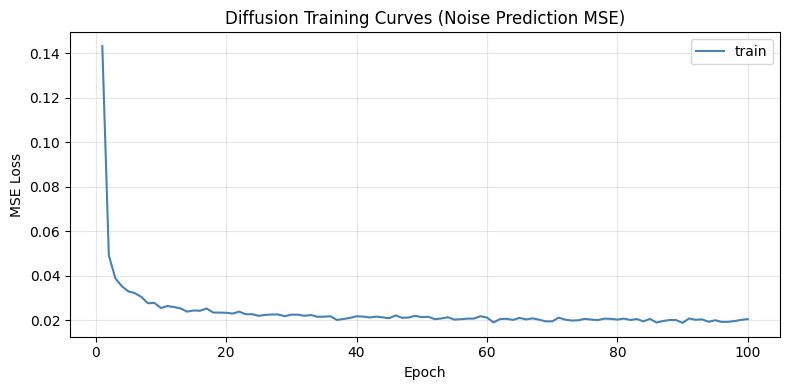

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\diffusion_training_curves.png


In [24]:
# Diffusion — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "diffusion_ep100_seed42" / "metrics.csv"
_fig_dir = _runs / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)

if _metrics.exists():
    ep, tr_loss = [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            tr_loss.append(float(row["train_loss"]))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ep, tr_loss, label="train", color="steelblue")
    ax.set_title("Diffusion Training Curves (Noise Prediction MSE)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(_fig_dir / "diffusion_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'diffusion_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


## Sample from Diffusion

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\diffusion_ep100_seed42
Loaded epoch: 90 | best_train_loss: 0.0187
hidden_dims: [64, 128, 256] | time_emb_dim: 256
Inference time (36 samples, 1000 steps): 14.29s  |  397 ms/image
Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\diffusion_samples.png


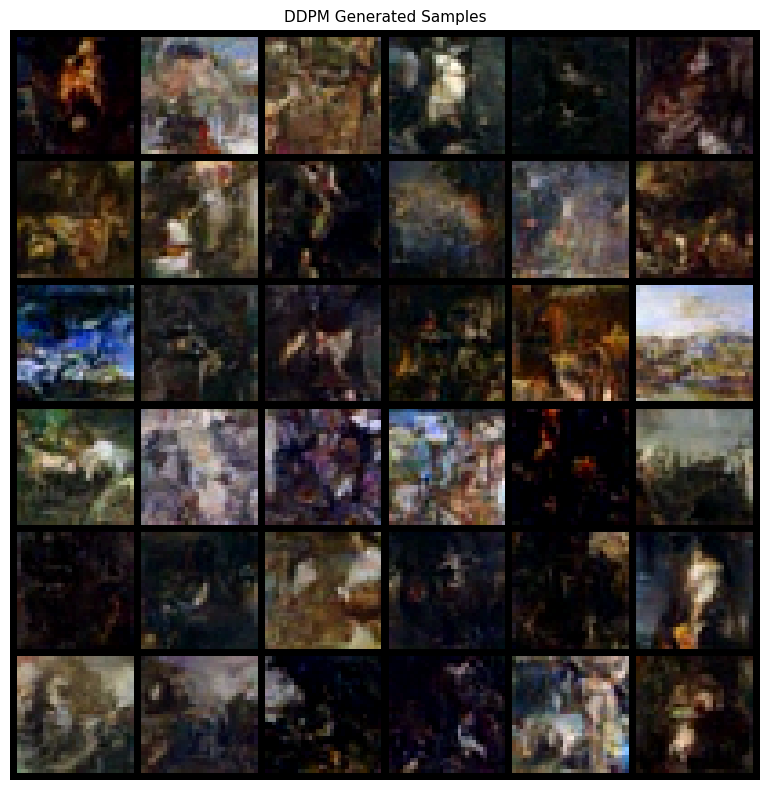

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\diffusion_ep100_seed42\samples\final_samples.png

Generating denoising trajectory (this takes ~same time as sampling 1 image)...
Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\diffusion_denoising_trajectory.png


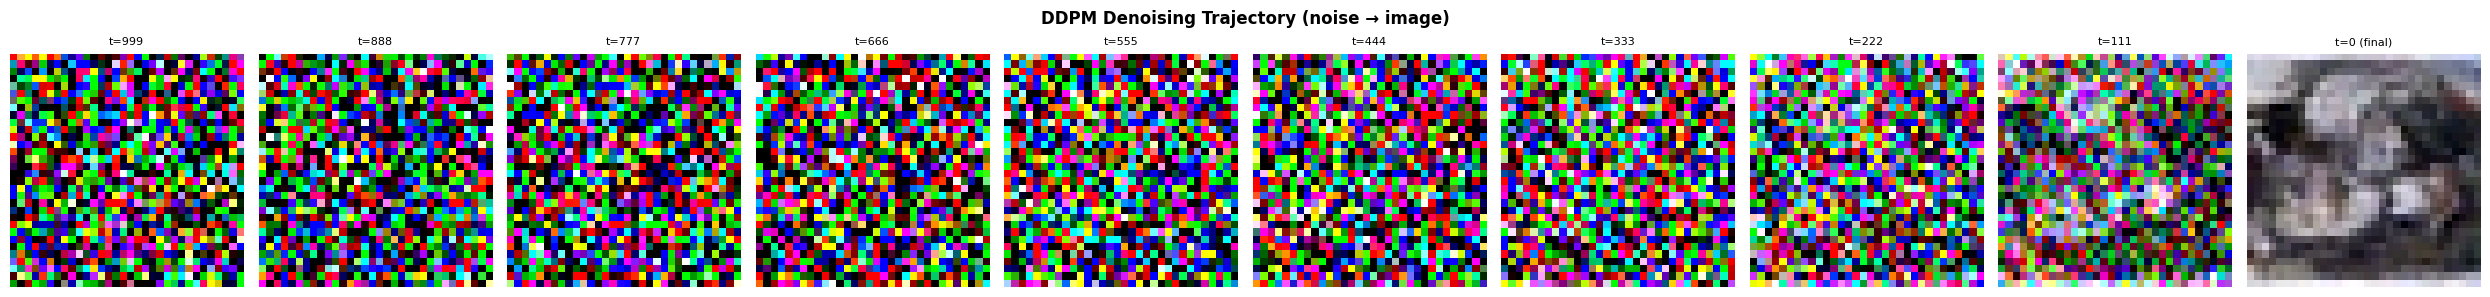

In [25]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_epochs = 100
seed = 42


def show_image_grid(images, n_images=36, nrow=6, title="Image Grid", save_path=None):
    images = images[:n_images].detach().cpu().clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np_img); ax.axis("off")
    if title: ax.set_title(title, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


def sample_denoising_trajectory(model, shape, device, n_frames=10):
    """Run full reverse diffusion on one image, capturing n_frames evenly spaced states."""
    model.eval()
    num_steps = model.num_steps
    timesteps = list(range(num_steps - 1, -1, -1))  # 999 → 0

    # indices to capture (evenly spaced, always include first and last)
    capture_at = set()
    for i in range(n_frames):
        idx = round(i * (len(timesteps) - 1) / (n_frames - 1))
        capture_at.add(idx)

    frames = []
    x = torch.randn(1, *shape, device=device)

    with torch.no_grad():
        for step_i, t_scalar in enumerate(timesteps):
            t = torch.full((1,), t_scalar, device=device, dtype=torch.long)

            beta_t        = model.scheduler.betas[t_scalar].view(1, 1, 1, 1)
            sqrt_1m_abar  = model.scheduler.sqrt_one_minus_alpha_cumprod[t_scalar].view(1, 1, 1, 1)
            sqrt_recip_a  = model.scheduler.sqrt_recip_alphas[t_scalar].view(1, 1, 1, 1)

            pred_noise = model.unet(x, t)
            model_mean = sqrt_recip_a * (x - beta_t * pred_noise / (sqrt_1m_abar + 1e-8))

            if t_scalar > 0:
                x = model_mean + torch.sqrt(beta_t) * torch.randn_like(x)
            else:
                x = model_mean

            if step_i in capture_at:
                frames.append(x.squeeze(0).clamp(0, 1).cpu())

    return frames  # list of n_frames tensors, each (C, H, W)


def show_denoising_trajectory(frames, save_path=None):
    n = len(frames)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1: axes = [axes]
    labels = [f"t={round(999 - i * 999 / (n - 1))}" for i in range(n)]
    labels[-1] = "t=0 (final)"
    for ax, frame, label in zip(axes, frames, labels):
        ax.imshow(frame.permute(1, 2, 0).numpy())
        ax.axis("off")
        ax.set_title(label, fontsize=8)
    fig.suptitle("DDPM Denoising Trajectory (noise → image)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


# ── Load checkpoint ──────────────────────────────────────────────
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

run_name = f"diffusion_ep{num_epochs}_seed{seed}"
run_dir  = base_runs_dir / run_name
best_ckpt_path = run_dir / "checkpoints" / "best_model.pt"
samples_dir = run_dir / "samples"
samples_dir.mkdir(parents=True, exist_ok=True)
_fig_dir = base_runs_dir / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)

print(f"Run dir: {run_dir}")

if not best_ckpt_path.exists():
    print(f"Checkpoint not found: {best_ckpt_path}")
else:
    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    cfg = checkpoint.get("config", {})

    model = Diffusion(
        img_channels=cfg.get("img_channels", 3),
        hidden_dims=cfg.get("hidden_dims", [64, 128, 256]),
        time_emb_dim=cfg.get("time_emb_dim", 256),
        num_steps=cfg.get("num_diffusion_steps", 1000),
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print(f"Loaded epoch: {checkpoint['epoch']} | best_train_loss: {checkpoint.get('best_train_loss', checkpoint.get('best_val_loss', '?')):.4f}")
    print(f"hidden_dims: {cfg.get('hidden_dims')} | time_emb_dim: {cfg.get('time_emb_dim')}")

    # ── 36-sample grid ───────────────────────────────────────────
    import time as _time_mod
    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():  # GPU warmup
        _ = model.sample(num_samples=1, shape=(3, IMAGE_SIZE, IMAGE_SIZE), device=device, num_inference_steps=None)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        samples = model.sample(
            num_samples=36,
            shape=(3, IMAGE_SIZE, IMAGE_SIZE),
            device=device,
            num_inference_steps=None,
        )
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference time (36 samples, 1000 steps): {_infer_time:.2f}s  |  {_infer_time/36*1000:.0f} ms/image")
    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["ddpm"] = {"time_36_samples_sec": round(_infer_time, 4), "ms_per_image": round(_infer_time/36*1000, 1), "steps": 1000}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    show_image_grid(samples, n_images=36, nrow=6, title="DDPM Generated Samples",
                    save_path=_fig_dir / "diffusion_samples.png")
    # also save to run samples folder
    from torchvision.utils import save_image
    save_image(samples, samples_dir / "final_samples.png", nrow=6)
    print(f"Saved: {samples_dir / 'final_samples.png'}")

    # ── Denoising trajectory (10 frames, noise → image) ─────────
    print("\nGenerating denoising trajectory (this takes ~same time as sampling 1 image)...")
    torch.manual_seed(seed + 1)
    traj_frames = sample_denoising_trajectory(
        model, shape=(3, IMAGE_SIZE, IMAGE_SIZE), device=device, n_frames=10
    )
    show_denoising_trajectory(traj_frames,
        save_path=_fig_dir / "diffusion_denoising_trajectory.png")


---
# DDIM

DDIM (Denoising Diffusion Implicit Models, Song et al. 2020) shares the same training objective as DDPM but uses a deterministic reverse process, enabling high-quality sampling with far fewer steps (e.g. 200 instead of 1000).


In [30]:
"""DDIM — Denoising Diffusion Implicit Models.

Training is identical to DDPM (predict noise, MSE loss).
Sampling is deterministic (eta=0) using a subsequence of timesteps.
Reuses UNet, DiffusionScheduler, and sinusoidal_embeddings from the DDPM section.
"""


class DDIM(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        hidden_dims: list[int] | None = None,
        time_emb_dim: int = 256,
        num_steps: int = 1000,
        beta_end: float = 0.02,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.num_steps = num_steps
        self.unet = UNet(
            img_channels=img_channels,
            hidden_dims=hidden_dims or [64, 128, 256],
            time_emb_dim=time_emb_dim,
            num_steps=num_steps,
            dropout=dropout,
        )
        self.scheduler = DiffusionScheduler(num_steps=num_steps, beta_end=beta_end)

    def forward(self, x_0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor | None = None) -> torch.Tensor:
        """Training forward: same as DDPM."""
        if noise is None:
            noise = torch.randn_like(x_0)
        x_t = self.scheduler.q_sample(x_0, t, noise)
        return self.unet(x_t, t)

    @torch.no_grad()
    def sample(self, num_samples: int, shape: tuple, device, num_inference_steps: int = 200) -> torch.Tensor:
        """Deterministic DDIM sampling (eta=0)."""
        self.eval()
        abar = self.scheduler.alpha_cumprod.to(device)

        # evenly spaced subsequence T-1 → 0
        step = max(1, self.num_steps // num_inference_steps)
        timesteps = torch.arange(self.num_steps - 1, -1, -step, device=device)[:num_inference_steps]

        x = torch.randn(num_samples, *shape, device=device)

        for i, t_scalar in enumerate(timesteps):
            t_idx      = int(t_scalar.item())
            t_prev_idx = int(timesteps[i + 1].item()) if i + 1 < len(timesteps) else -1

            abar_t    = abar[t_idx]
            abar_prev = abar[t_prev_idx] if t_prev_idx >= 0 else torch.ones(1, device=device).squeeze()

            t_batch = torch.full((num_samples,), t_idx, device=device, dtype=torch.long)
            eps = self.unet(x, t_batch)

            # predicted x0
            x0_pred = (x - torch.sqrt(1 - abar_t) * eps) / (torch.sqrt(abar_t) + 1e-8)
            x0_pred = x0_pred.clamp(-1, 1)

            # DDIM step (deterministic)
            x = torch.sqrt(abar_prev) * x0_pred + torch.sqrt(1 - abar_prev) * eps

        return x.clamp(0, 1)


## Train DDIM

In [31]:
import os
import gc
import json
import time
import csv
from pathlib import Path

import torch.nn.functional as F
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEED = 42
seed = SEED
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

base_runs_dir = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
base_runs_dir.mkdir(parents=True, exist_ok=True)

ddim_hidden_dims   = [64, 128, 256]
ddim_time_emb_dim  = 256
num_epochs         = 100
learning_rate      = 2e-4
weight_decay       = 0.0
num_diffusion_steps = 1000
ddim_infer_steps   = 200   # steps used at sampling time

img_channels = 3
img_size     = IMAGE_SIZE

summary_csv_path = base_runs_dir / "ddim_summary.csv"


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)


def train_ddim():
    run_name = f"ddim_ep{num_epochs}_seed{seed}"
    run_dir  = base_runs_dir / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    ckpt_dir    = run_dir / "checkpoints"; ckpt_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = run_dir / "samples";     samples_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path  = ckpt_dir / "best_model.pt"
    final_ckpt_path = ckpt_dir / "final_model.pt"
    config_json     = run_dir / "config.json"
    metrics_csv     = run_dir / "metrics.csv"

    hidden_dims   = ddim_hidden_dims
    time_emb_dim  = ddim_time_emb_dim

    config = {
        "run_name": run_name,
        "num_epochs": num_epochs,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "img_channels": img_channels,
        "img_size": img_size,
        "hidden_dims": hidden_dims,
        "time_emb_dim": time_emb_dim,
        "num_diffusion_steps": num_diffusion_steps,
        "ddim_infer_steps": ddim_infer_steps,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
    }
    save_json(config, config_json)

    model = DDIM(
        img_channels=img_channels,
        hidden_dims=hidden_dims,
        time_emb_dim=time_emb_dim,
        num_steps=num_diffusion_steps,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    with open(metrics_csv, "w", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writeheader()

    best_train_loss = float("inf")
    best_epoch      = -1
    start_time      = time.time()

    print("\n" + "=" * 100)
    print(f"Starting: {run_name}")
    print(f"Train size: {len(train_loader_from_csv.dataset)} | Steps: {num_diffusion_steps} | DDIM infer: {ddim_infer_steps}")
    print("=" * 100)

    for epoch in range(num_epochs):
        model.train()
        loss_sum, n_batches = 0.0, 0

        for batch in train_loader_from_csv:
            x0 = batch[0].to(device, non_blocking=True)
            t  = torch.randint(0, num_diffusion_steps, (x0.size(0),), device=device).long()
            noise = torch.randn_like(x0)

            pred_noise = model(x0, t, noise)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            n_batches += 1

        train_loss = loss_sum / max(n_batches, 1)

        with open(metrics_csv, "a", newline="", encoding="utf-8") as f:
            csv.DictWriter(f, fieldnames=["epoch", "train_loss"]).writerow(
                {"epoch": epoch + 1, "train_loss": train_loss}
            )

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_epoch      = epoch + 1
            torch.save({"epoch": best_epoch, "model_state_dict": model.state_dict(),
                        "best_train_loss": best_train_loss, "config": config}, best_ckpt_path)

        print(f"Epoch {epoch+1:>3}/{num_epochs} | train_loss={train_loss:.4f}")

    total_time = time.time() - start_time

    torch.save({"epoch": num_epochs, "model_state_dict": model.state_dict(),
                "best_train_loss": best_train_loss, "best_epoch": best_epoch,
                "config": config}, final_ckpt_path)

    summary_row = {
        "run_name": run_name, "num_epochs": num_epochs,
        "best_epoch": best_epoch, "best_train_loss": best_train_loss,
        "train_size": len(train_loader_from_csv.dataset),
        "batch_size": train_loader_from_csv.batch_size,
        "run_dir": str(run_dir), "best_ckpt_path": str(best_ckpt_path),
        "final_ckpt_path": str(final_ckpt_path),
        "time_sec": total_time, "status": "ok",
    }

    print("-" * 100)
    print(f"Done | best_train_loss={best_train_loss:.4f} | best_epoch={best_epoch} | time={total_time/60:.1f} min")
    print("-" * 100)
    return summary_row


summary_fieldnames = [
    "run_name", "num_epochs", "best_epoch", "best_train_loss",
    "train_size", "batch_size", "run_dir",
    "best_ckpt_path", "final_ckpt_path", "time_sec", "status",
]

with open(summary_csv_path, "w", newline="", encoding="utf-8") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writeheader()

try:
    result = train_ddim()
except RuntimeError as e:
    result = {k: None for k in summary_fieldnames}
    result.update({"status": f"error: {e}", "run_name": f"ddim_ep{num_epochs}_seed{seed}"})
    print(f"Training failed: {e}")

with open(summary_csv_path, "a", newline="", encoding="utf-8") as f:
    csv.DictWriter(f, fieldnames=summary_fieldnames).writerow(result)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nSummary saved to: {summary_csv_path}")


Device: cuda

Starting: ddim_ep100_seed42
Train size: 10000 | Steps: 1000 | DDIM infer: 200
Epoch   1/100 | train_loss=0.1433
Epoch   2/100 | train_loss=0.0492
Epoch   3/100 | train_loss=0.0388
Epoch   4/100 | train_loss=0.0352
Epoch   5/100 | train_loss=0.0329
Epoch   6/100 | train_loss=0.0321
Epoch   7/100 | train_loss=0.0304
Epoch   8/100 | train_loss=0.0276
Epoch   9/100 | train_loss=0.0277
Epoch  10/100 | train_loss=0.0254
Epoch  11/100 | train_loss=0.0263
Epoch  12/100 | train_loss=0.0259
Epoch  13/100 | train_loss=0.0253
Epoch  14/100 | train_loss=0.0238
Epoch  15/100 | train_loss=0.0243
Epoch  16/100 | train_loss=0.0242
Epoch  17/100 | train_loss=0.0252
Epoch  18/100 | train_loss=0.0234
Epoch  19/100 | train_loss=0.0234
Epoch  20/100 | train_loss=0.0233
Epoch  21/100 | train_loss=0.0229
Epoch  22/100 | train_loss=0.0238
Epoch  23/100 | train_loss=0.0226
Epoch  24/100 | train_loss=0.0226
Epoch  25/100 | train_loss=0.0219
Epoch  26/100 | train_loss=0.0223
Epoch  27/100 | train_lo

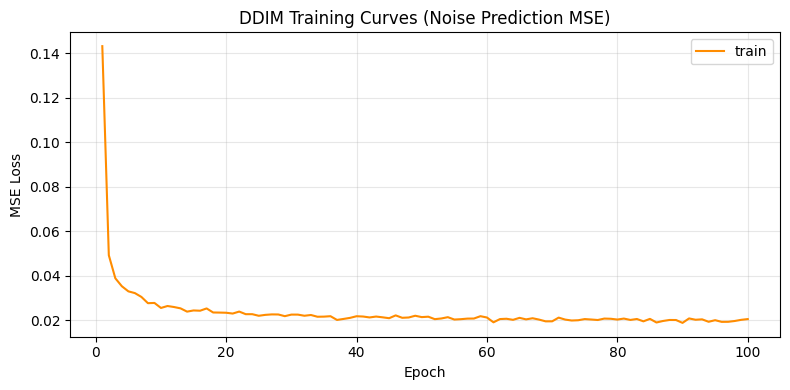

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\ddim_training_curves.png


In [32]:
# DDIM — Loss Curves
import csv
import matplotlib.pyplot as plt
from pathlib import Path

_runs    = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_metrics = _runs / "ddim_ep100_seed42" / "metrics.csv"
_fig_dir = _runs / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)

if _metrics.exists():
    ep, tr_loss = [], []
    with open(_metrics) as f:
        for row in csv.DictReader(f):
            ep.append(int(row["epoch"]))
            tr_loss.append(float(row["train_loss"]))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(ep, tr_loss, label="train", color="darkorange")
    ax.set_title("DDIM Training Curves (Noise Prediction MSE)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(_fig_dir / "ddim_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'ddim_training_curves.png'}")
else:
    print(f"Metrics not found: {_metrics}. Run training first.")


## Sample from DDIM

Run dir: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\ddim_ep100_seed42
Loaded epoch: 90 | best_train_loss: 0.0187
Inference time (36 samples, 200 steps): 2.83s  |  79 ms/image


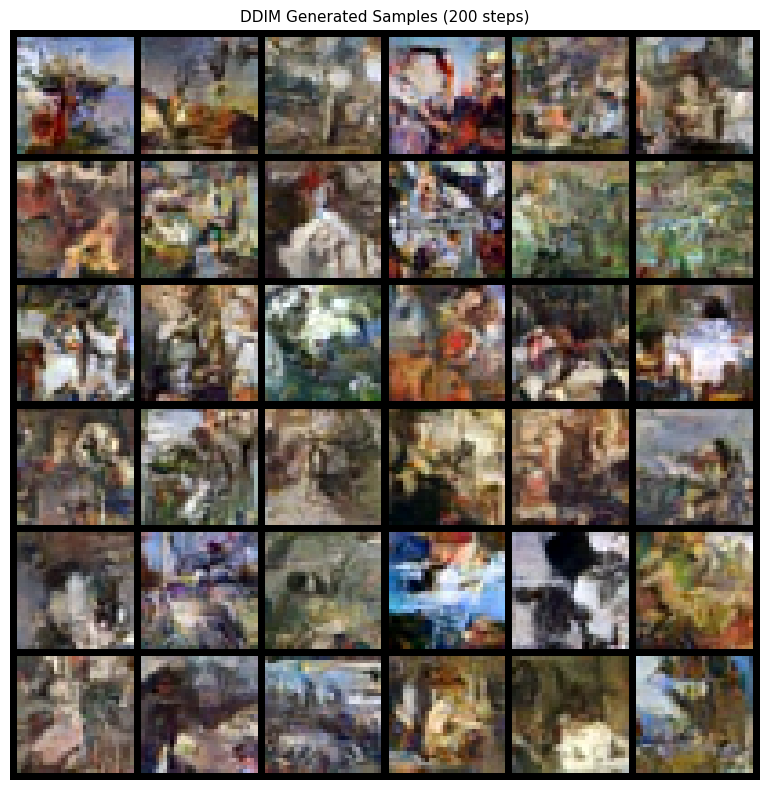

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\ddim_samples.png
Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\ddim_ep100_seed42\samples\final_samples.png

Generating denoising trajectory...
Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\ddim_denoising_trajectory.png


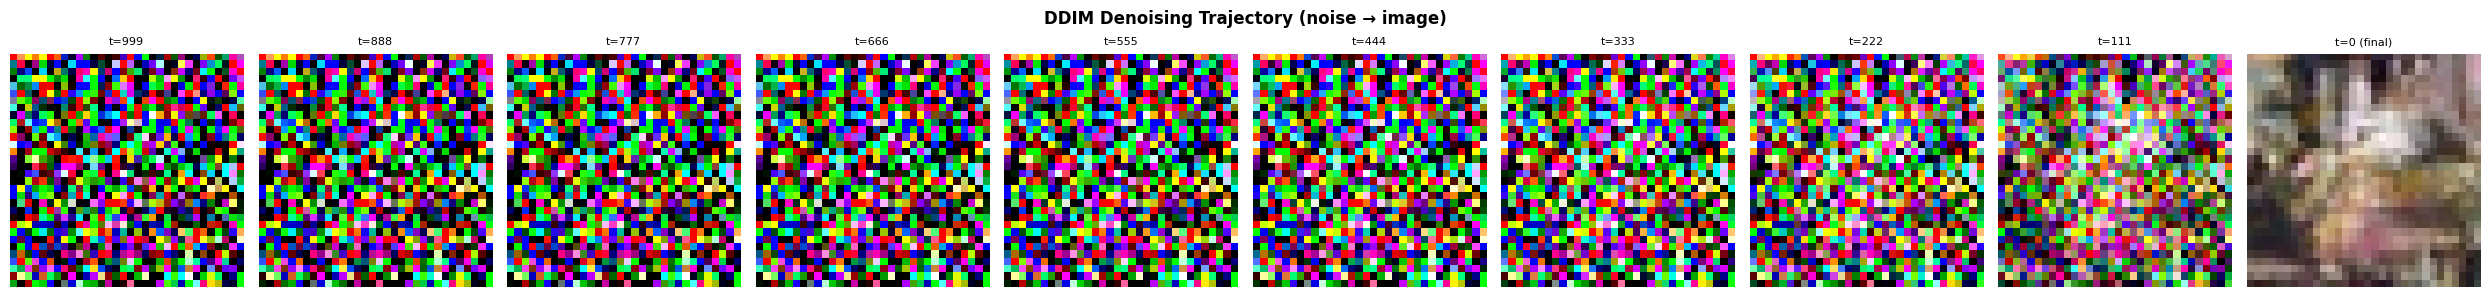

In [34]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image
from pathlib import Path

base_runs_dir = (PROJECT_ROOT / "runs") if "PROJECT_ROOT" in globals() else Path("runs")
_fig_dir = base_runs_dir / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_epochs      = 100
seed            = 42
ddim_infer_steps = 200


def save_image_grid(images, save_path, n_images=36, nrow=6, title=""):
    images = images[:n_images].detach().cpu().clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).numpy()
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(np_img); ax.axis("off")
    if title: ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def sample_denoising_trajectory_ddim(model, shape, device, n_frames=10, num_inference_steps=200):
    """Run DDIM reverse process, capturing n_frames evenly spaced states."""
    model.eval()
    abar = model.scheduler.alpha_cumprod.to(device)

    step = max(1, model.num_steps // num_inference_steps)
    timesteps = torch.arange(model.num_steps - 1, -1, -step, device=device)[:num_inference_steps]

    capture_at = {round(i * (len(timesteps) - 1) / (n_frames - 1)) for i in range(n_frames)}
    frames = []
    x = torch.randn(1, *shape, device=device)

    with torch.no_grad():
        for step_i, t_scalar in enumerate(timesteps):
            t_idx      = int(t_scalar.item())
            t_prev_idx = int(timesteps[step_i + 1].item()) if step_i + 1 < len(timesteps) else -1

            abar_t    = abar[t_idx]
            abar_prev = abar[t_prev_idx] if t_prev_idx >= 0 else torch.ones(1, device=device).squeeze()

            t_batch = torch.full((1,), t_idx, device=device, dtype=torch.long)
            eps = model.unet(x, t_batch)

            x0_pred = (x - torch.sqrt(1 - abar_t) * eps) / (torch.sqrt(abar_t) + 1e-8)
            x0_pred = x0_pred.clamp(-1, 1)
            x = torch.sqrt(abar_prev) * x0_pred + torch.sqrt(1 - abar_prev) * eps

            if step_i in capture_at:
                frames.append(x.squeeze(0).clamp(0, 1).cpu())

    return frames


def show_denoising_trajectory(frames, save_path=None):
    n = len(frames)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1: axes = [axes]
    labels = [f"t={round(999 - i * 999 / (n - 1))}" for i in range(n)]
    labels[-1] = "t=0 (final)"
    for ax, frame, label in zip(axes, frames, labels):
        ax.imshow(frame.permute(1, 2, 0).numpy())
        ax.axis("off"); ax.set_title(label, fontsize=8)
    fig.suptitle("DDIM Denoising Trajectory (noise → image)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


# ── Load checkpoint ──────────────────────────────────────────────
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

run_name = f"ddim_ep{num_epochs}_seed{seed}"
run_dir  = base_runs_dir / run_name
best_ckpt_path = run_dir / "checkpoints" / "best_model.pt"
samples_dir    = run_dir / "samples"
samples_dir.mkdir(parents=True, exist_ok=True)

print(f"Run dir: {run_dir}")

if not best_ckpt_path.exists():
    print(f"Checkpoint not found: {best_ckpt_path}")
else:
    checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
    cfg = checkpoint.get("config", {})

    model = DDIM(
        img_channels=cfg.get("img_channels", 3),
        hidden_dims=cfg.get("hidden_dims", [64, 128, 256]),
        time_emb_dim=cfg.get("time_emb_dim", 256),
        num_steps=cfg.get("num_diffusion_steps", 1000),
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    print(f"Loaded epoch: {checkpoint['epoch']} | best_train_loss: {checkpoint['best_train_loss']:.4f}")

    # ── 36-sample grid ───────────────────────────────────────────
    import time as _time_mod
    # ── Inference timing ────────────────────────────────────────────
    with torch.no_grad():  # GPU warmup
        _ = model.sample(num_samples=1, shape=(3, IMAGE_SIZE, IMAGE_SIZE), device=device, num_inference_steps=ddim_infer_steps)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _t0 = _time_mod.time()
    with torch.no_grad():
        samples = model.sample(
            num_samples=36,
            shape=(3, IMAGE_SIZE, IMAGE_SIZE),
            device=device,
            num_inference_steps=ddim_infer_steps,
        )
    if torch.cuda.is_available(): torch.cuda.synchronize()
    _infer_time = _time_mod.time() - _t0
    print(f"Inference time (36 samples, {ddim_infer_steps} steps): {_infer_time:.2f}s  |  {_infer_time/36*1000:.0f} ms/image")
    import json as _jj
    _it_path = base_runs_dir / "inference_times.json"
    _it = _jj.load(open(_it_path)) if _it_path.exists() else {}
    _it["ddim"] = {"time_36_samples_sec": round(_infer_time, 4), "ms_per_image": round(_infer_time/36*1000, 1), "steps": ddim_infer_steps}
    _jj.dump(_it, open(_it_path, "w"), indent=2)

    save_image_grid(samples, save_path=_fig_dir / "ddim_samples.png",
                    n_images=36, nrow=6, title=f"DDIM Generated Samples ({ddim_infer_steps} steps)")
    save_image(samples, samples_dir / "final_samples.png", nrow=6)
    print(f"Saved: {samples_dir / 'final_samples.png'}")

    # ── Denoising trajectory ─────────────────────────────────────
    print("\nGenerating denoising trajectory...")
    torch.manual_seed(seed + 1)
    traj_frames = sample_denoising_trajectory_ddim(
        model, shape=(3, IMAGE_SIZE, IMAGE_SIZE),
        device=device, n_frames=10, num_inference_steps=ddim_infer_steps,
    )
    show_denoising_trajectory(traj_frames,
        save_path=_fig_dir / "ddim_denoising_trajectory.png")


Model     Train (min)   Infer (ms/img)
--------------------------------------
VAE               9.2              0.1
DCGAN            10.0              0.0
DDPM             24.9            397.1
DDIM             24.5             78.6


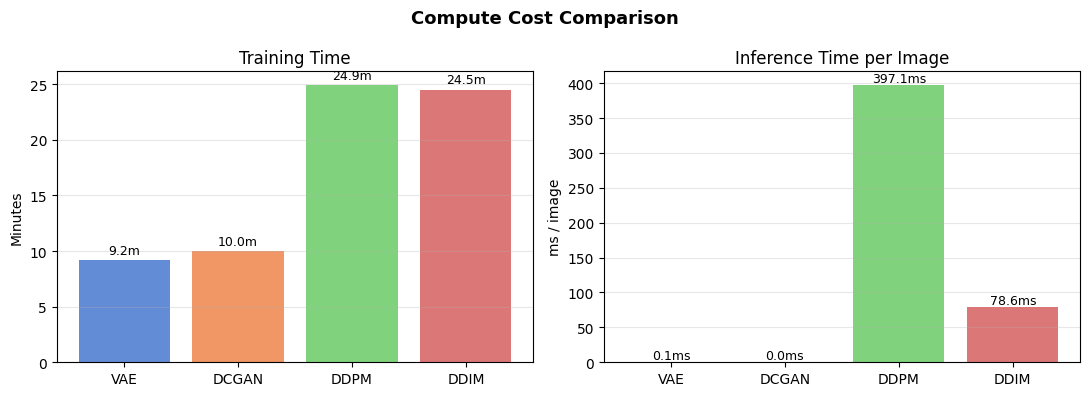

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\timing_comparison.png


In [35]:
# ── Training & Inference Time Summary ────────────────────────────
import csv, json as _j, matplotlib.pyplot as plt, numpy as np
from pathlib import Path

_runs    = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_fig_dir = _runs / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)

# ── Training times from summary CSVs ─────────────────────────────
_train_times = {}
_csv_map = {
    "VAE":    _runs / "summary_vae.csv",
    "DCGAN":  _runs / "summary_dcgan.csv",
    "DDPM":   _runs / "diffusion_summary.csv",
    "DDIM":   _runs / "ddim_summary.csv",
}
for name, path in _csv_map.items():
    if path.exists():
        with open(path) as f:
            rows = list(csv.DictReader(f))
        ok = [r for r in rows if r.get("status") == "ok"]
        if ok:
            _train_times[name] = float(ok[0]["time_sec"]) / 60  # convert to minutes

# ── Inference times from JSON ─────────────────────────────────────
_infer_times = {}
_it_path = _runs / "inference_times.json"
_key_map = {"vae": "VAE", "dcgan": "DCGAN", "ddpm": "DDPM", "ddim": "DDIM"}
if _it_path.exists():
    _it = _j.load(open(_it_path))
    for k, label in _key_map.items():
        if k in _it:
            _infer_times[label] = _it[k]["ms_per_image"]

# ── Print table ───────────────────────────────────────────────────
print(f"{'Model':<8} {'Train (min)':>12} {'Infer (ms/img)':>16}")
print("-" * 38)
for m in ["VAE", "DCGAN", "DDPM", "DDIM"]:
    tr  = f"{_train_times[m]:.1f}"  if m in _train_times  else "—"
    inf = f"{_infer_times[m]:.1f}" if m in _infer_times else "—"
    print(f"{m:<8} {tr:>12} {inf:>16}")

# ── Bar charts ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colors = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f"]

if _train_times:
    labels = list(_train_times.keys())
    vals   = list(_train_times.values())
    bars = ax1.bar(labels, vals, color=colors[:len(labels)], alpha=0.85)
    ax1.set_ylabel("Minutes"); ax1.set_title("Training Time")
    ax1.grid(True, alpha=0.3, axis="y")
    for b, v in zip(bars, vals):
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f"{v:.1f}m", ha="center", va="bottom", fontsize=9)

if _infer_times:
    labels2 = list(_infer_times.keys())
    vals2   = list(_infer_times.values())
    bars2 = ax2.bar(labels2, vals2, color=colors[:len(labels2)], alpha=0.85)
    ax2.set_ylabel("ms / image"); ax2.set_title("Inference Time per Image")
    ax2.grid(True, alpha=0.3, axis="y")
    for b, v in zip(bars2, vals2):
        ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                 f"{v:.1f}ms", ha="center", va="bottom", fontsize=9)

fig.suptitle("Compute Cost Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(_fig_dir / "timing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_fig_dir / 'timing_comparison.png'}")


# Evaluation: FID and KID computation.

In [36]:
"""
Evaluation: FID and KID computation.
Requires: pip install torchmetrics[image]
"""

import numpy as np
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance


def generate_samples(model, model_type, num_samples, latent_dim, img_channels, img_size, device, num_inference_steps=None):
    """Generate samples. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    model.eval()
    model.to(device)
    results = []
    batch_size = 64
    with torch.no_grad():
        generated = 0
        while generated < num_samples:
            n = min(batch_size, num_samples - generated)
            if model_type == "vae":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model.decode(z)
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "gan":
                z = torch.randn(n, latent_dim, device=device)
                imgs = model(z)
                imgs = (imgs + 1.0) / 2.0
                imgs = torch.clamp(imgs, 0.0, 1.0)
            elif model_type == "diffusion":
                imgs = model.sample(
                    num_samples=n,
                    shape=(img_channels, img_size, img_size),
                    device=device,
                    num_inference_steps=num_inference_steps,
                )
                imgs = torch.clamp(imgs, 0.0, 1.0)
            else:
                raise ValueError(f"Unknown model_type: {model_type}")
            results.append((imgs * 255).byte().cpu())
            generated += n
    return torch.cat(results, dim=0)[:num_samples]


def get_real_samples(dataset, num_samples, seed):
    """Sample real images from dataset. Returns uint8 tensor (N, C, H, W) in [0, 255]."""
    rng = torch.Generator()
    rng.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=rng)[:num_samples].tolist()
    subset = Subset(dataset, indices)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=0)
    imgs_list = []
    for batch in loader:
        imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
        imgs_list.append((imgs * 255).byte())
    return torch.cat(imgs_list, dim=0)[:num_samples]


def compute_fid_kid_single(fake_imgs_uint8, real_imgs_uint8, kid_subset_size, device):
    """Compute FID and KID. Returns (fid, kid_mean, kid_std)."""
    bs = 128
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        fid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        fid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    fid_val = fid_metric.compute().item()
    del fid_metric

    kid_metric = KernelInceptionDistance(subset_size=kid_subset_size, normalize=False).to(device)
    for i in range(0, len(real_imgs_uint8), bs):
        kid_metric.update(real_imgs_uint8[i:i+bs].to(device), real=True)
    for i in range(0, len(fake_imgs_uint8), bs):
        kid_metric.update(fake_imgs_uint8[i:i+bs].to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()
    del kid_metric

    return fid_val, kid_mean.item(), kid_std.item()


def evaluate_model(
    model,
    real_dataset,
    model_type,
    latent_dim=128,
    img_channels=3,
    img_size=32,
    num_generated=5000,
    num_real=5000,
    kid_subset_size=100,
    n_repetitions=10,
    base_seed=0,
    device="cuda",
    num_inference_steps=None,
):
    """Full evaluation: n_repetitions with different seeds. Reports mean±std of FID and KID."""
    fid_list, kid_mean_list = [], []
    for rep in range(n_repetitions):
        seed = base_seed + rep * 137
        torch.manual_seed(seed)
        np.random.seed(seed)
        fake_imgs = generate_samples(model, model_type, num_generated, latent_dim, img_channels, img_size, device, num_inference_steps)
        real_imgs = get_real_samples(real_dataset, num_real, seed)
        fid, kid_m, kid_s = compute_fid_kid_single(fake_imgs, real_imgs, kid_subset_size, device)
        fid_list.append(fid)
        kid_mean_list.append(kid_m)
        print(f"  [{model_type}] Rep {rep+1}/{n_repetitions} seed={seed} | FID={fid:.2f} | KID={kid_m*1000:.4f}±{kid_s*1000:.4f} (×10⁻³)")

    results = {
        "model_type": model_type,
        "fid_mean": float(np.mean(fid_list)),
        "fid_std": float(np.std(fid_list)),
        "kid_mean": float(np.mean(kid_mean_list)),
        "kid_std": float(np.std(kid_mean_list)),
        "n_repetitions": n_repetitions,
        "num_generated": num_generated,
        "num_real": num_real,
    }
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} | FID: {results['fid_mean']:.2f} ± {results['fid_std']:.2f} | KID: {results['kid_mean']*1000:.4f} ± {results['kid_std']*1000:.4f} (×10⁻³)")
    print(f"{'='*60}\n")
    return results


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [37]:
# ── FID/KID evaluation — shared config & helpers ─────────────────
import csv as _csv
import json as _json
from pathlib import Path

EVAL_NUM_GENERATED = 5000
EVAL_NUM_REAL      = 5000
EVAL_KID_SUBSET    = 100
EVAL_N_REPS        = 10
EVAL_BASE_SEED     = 0
EVAL_DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_runs        = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_results_out = _runs / "evaluation_results.json"


def _best_row(csv_path, key_col, lower_is_better=True):
    if not Path(csv_path).exists():
        return None
    rows = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in _csv.DictReader(f):
            if row.get("status") == "ok":
                try:
                    rows.append((float(row[key_col]), row))
                except (ValueError, KeyError):
                    pass
    if not rows:
        return None
    rows.sort(key=lambda x: x[0], reverse=not lower_is_better)
    return rows[0][1]


def _load_results():
    if _results_out.exists():
        with open(_results_out) as f:
            return _json.load(f)
    return {}


def _save_results(d):
    _runs.mkdir(parents=True, exist_ok=True)
    with open(_results_out, "w") as f:
        _json.dump(d, f, indent=2)
    print(f"Saved → {_results_out}")


def _print_results(d):
    if not d:
        print("No results yet.")
        return
    print(f"\n{'Model':<12} {'FID':>10} {'FID±':>8} {'KID×10³':>12} {'KID±×10³':>12}")
    print("-" * 56)
    for name, res in d.items():
        print(
            f"{name.upper():<12} "
            f"{res['fid_mean']:>10.2f} "
            f"{res['fid_std']:>8.2f} "
            f"{res['kid_mean']*1000:>12.4f} "
            f"{res['kid_std']*1000:>12.4f}"
        )

print("FID/KID config ready. Run each model cell independently.")
print(f"Results file: {_results_out}")
if _results_out.exists():
    _print_results(_load_results())


FID/KID config ready. Run each model cell independently.
Results file: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\evaluation_results.json


In [38]:
# ── VAE — FID/KID ────────────────────────────────────────────────
_vae_row       = _best_row(_runs / "summary_vae.csv", "best_train_loss")
_vae_ckpt_path = Path(_vae_row["best_ckpt_path"]) if _vae_row else None

if _vae_ckpt_path and _vae_ckpt_path.exists():
    print(f"[VAE] Loading from: {_vae_ckpt_path}")
    _ckpt  = torch.load(_vae_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = VAE(
        img_channels=_cfg["img_channels"],
        image_size=_cfg["image_size"],
        latent_dim=_cfg["latent_dim"],
        hidden_dims=_cfg["hidden_dims"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="vae",
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"], img_size=_cfg["image_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["vae"] = _res
    _save_results(_all)
    _print_results({"vae": _res})
else:
    print(f"[VAE] Checkpoint not found — skipping. (path={_vae_ckpt_path})")


[VAE] Loading from: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\vae_ldim256_ep100_seed42\best_model.pt


c:\Users\User\source\repos\genai-project1\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


  [vae] Rep 1/10 seed=0 | FID=242.31 | KID=241.8745±10.2829 (×10⁻³)
  [vae] Rep 2/10 seed=137 | FID=241.95 | KID=241.4398±10.3085 (×10⁻³)
  [vae] Rep 3/10 seed=274 | FID=243.08 | KID=243.1791±10.4004 (×10⁻³)
  [vae] Rep 4/10 seed=411 | FID=242.38 | KID=242.3563±9.6837 (×10⁻³)
  [vae] Rep 5/10 seed=548 | FID=243.42 | KID=244.9619±11.6706 (×10⁻³)
  [vae] Rep 6/10 seed=685 | FID=243.86 | KID=244.5516±11.6951 (×10⁻³)
  [vae] Rep 7/10 seed=822 | FID=242.17 | KID=240.8365±10.1206 (×10⁻³)
  [vae] Rep 8/10 seed=959 | FID=243.72 | KID=240.8745±11.3833 (×10⁻³)
  [vae] Rep 9/10 seed=1096 | FID=243.80 | KID=244.3900±11.0556 (×10⁻³)
  [vae] Rep 10/10 seed=1233 | FID=243.14 | KID=243.9319±10.3374 (×10⁻³)

  VAE | FID: 242.98 ± 0.69 | KID: 242.8396 ± 1.4881 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\drive_outputs\runs\evaluation_results.json

Model               FID     FID±      KID×10³     KID±×10³
--------------------------------------------------------
VAE              242.98     

In [39]:
# ── GAN — FID/KID ────────────────────────────────────────────────
_gan_row       = _best_row(_runs / "summary_dcgan.csv", "final_g_loss")
_gan_ckpt_path = Path(_gan_row["final_g_path"]) if _gan_row else None

if _gan_ckpt_path and _gan_ckpt_path.exists():
    print(f"[DCGAN] Loading from: {_gan_ckpt_path}")
    _ckpt  = torch.load(_gan_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Generator(
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"],
        img_size=_cfg["img_size"],
        hidden_dims=_cfg["hidden_dims"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="gan",
        latent_dim=_cfg["latent_dim"],
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["gan"] = _res
    _save_results(_all)
    _print_results({"gan": _res})
else:
    print(f"[DCGAN] Checkpoint not found — skipping. (path={_gan_ckpt_path})")


[DCGAN] Loading from: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\dcgan_ldim256_ep100_seed42\final_generator.pt
  [gan] Rep 1/10 seed=0 | FID=87.10 | KID=64.5509±6.4075 (×10⁻³)
  [gan] Rep 2/10 seed=137 | FID=87.40 | KID=63.5296±5.9606 (×10⁻³)
  [gan] Rep 3/10 seed=274 | FID=88.97 | KID=66.7450±7.2851 (×10⁻³)
  [gan] Rep 4/10 seed=411 | FID=88.09 | KID=65.5884±6.2219 (×10⁻³)
  [gan] Rep 5/10 seed=548 | FID=88.66 | KID=65.8331±6.1272 (×10⁻³)
  [gan] Rep 6/10 seed=685 | FID=89.01 | KID=66.5977±6.8023 (×10⁻³)
  [gan] Rep 7/10 seed=822 | FID=89.04 | KID=65.6640±7.6653 (×10⁻³)
  [gan] Rep 8/10 seed=959 | FID=88.80 | KID=65.2462±7.7996 (×10⁻³)
  [gan] Rep 9/10 seed=1096 | FID=89.86 | KID=67.9282±6.5591 (×10⁻³)
  [gan] Rep 10/10 seed=1233 | FID=89.85 | KID=66.0957±6.3473 (×10⁻³)

  GAN | FID: 88.68 ± 0.87 | KID: 65.7779 ± 1.1501 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\drive_outputs\runs\evaluation_results.json

Model               FID     FID±      KID×10³ 

In [40]:
# ── Diffusion — FID/KID ──────────────────────────────────────────
_diff_ckpt_path = _runs / "diffusion_ep100_seed42" / "checkpoints" / "best_model.pt"
if not _diff_ckpt_path.exists():
    _diff_ckpt_path = _runs / "diffusion_ep100_seed42" / "checkpoints" / "final_model.pt"

if _diff_ckpt_path.exists():
    print(f"[Diffusion] Loading from: {_diff_ckpt_path}")
    _ckpt  = torch.load(_diff_ckpt_path, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = Diffusion(
        img_channels=_cfg["img_channels"],
        hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"],
        num_steps=_cfg["num_diffusion_steps"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="diffusion",
        latent_dim=0,  # unused for diffusion
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
        num_inference_steps=None,  # full 1000 steps
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["diffusion"] = _res
    _save_results(_all)
    _print_results({"diffusion": _res})
else:
    print(f"[Diffusion] Checkpoint not found at {_diff_ckpt_path} — skipping.")


[Diffusion] Loading from: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\diffusion_ep100_seed42\checkpoints\best_model.pt
  [diffusion] Rep 1/10 seed=0 | FID=146.93 | KID=146.9328±11.6337 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=146.27 | KID=144.6826±11.6270 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=147.63 | KID=148.0297±12.9445 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=147.27 | KID=146.3350±12.2950 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=147.71 | KID=147.2797±11.8259 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=148.26 | KID=149.3883±11.9343 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=149.97 | KID=148.1365±13.0089 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=147.84 | KID=145.0987±13.8248 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=150.71 | KID=149.1176±11.7409 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=148.23 | KID=144.5891±12.3211 (×10⁻³)

  DIFFUSION | FID: 148.08 ± 1.27 | KID: 146.9590 ± 1.6687 (×10⁻³)

Saved → c:\Users\User\source\repos\

In [41]:
# ── DDIM — FID/KID ───────────────────────────────────────────────
import csv as _csv
from pathlib import Path

_ddim_run   = _runs / "ddim_ep100_seed42"
_ddim_ckpt  = _ddim_run / "checkpoints" / "best_model.pt"
if not _ddim_ckpt.exists():
    _ddim_ckpt = _ddim_run / "checkpoints" / "final_model.pt"

DDIM_INFER_STEPS = 200

if _ddim_ckpt.exists():
    print(f"[DDIM] Loading from: {_ddim_ckpt}")
    _ckpt  = torch.load(_ddim_ckpt, map_location=EVAL_DEVICE, weights_only=False)
    _cfg   = _ckpt["config"]
    _model = DDIM(
        img_channels=_cfg["img_channels"],
        hidden_dims=_cfg["hidden_dims"],
        time_emb_dim=_cfg["time_emb_dim"],
        num_steps=_cfg["num_diffusion_steps"],
    ).to(EVAL_DEVICE)
    _model.load_state_dict(_ckpt["model_state_dict"])
    _model.eval()

    _res = evaluate_model(
        model=_model, real_dataset=test_ds, model_type="diffusion",
        latent_dim=0,
        img_channels=_cfg["img_channels"], img_size=_cfg["img_size"],
        num_generated=EVAL_NUM_GENERATED, num_real=EVAL_NUM_REAL,
        kid_subset_size=EVAL_KID_SUBSET, n_repetitions=EVAL_N_REPS,
        base_seed=EVAL_BASE_SEED, device=EVAL_DEVICE,
        num_inference_steps=DDIM_INFER_STEPS,
    )
    del _model, _ckpt
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    _all = _load_results()
    _all["ddim"] = _res
    _save_results(_all)
    _print_results({"ddim": _res})
    print(f"(sampled with {DDIM_INFER_STEPS} steps — {1000 // DDIM_INFER_STEPS}× faster than DDPM)")
else:
    print(f"[DDIM] Checkpoint not found at {_ddim_ckpt} — skipping.")


[DDIM] Loading from: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\ddim_ep100_seed42\checkpoints\best_model.pt
  [diffusion] Rep 1/10 seed=0 | FID=97.34 | KID=87.9207±7.4540 (×10⁻³)
  [diffusion] Rep 2/10 seed=137 | FID=97.00 | KID=87.9228±7.9139 (×10⁻³)
  [diffusion] Rep 3/10 seed=274 | FID=97.38 | KID=88.7688±8.5570 (×10⁻³)
  [diffusion] Rep 4/10 seed=411 | FID=96.87 | KID=86.8356±7.8747 (×10⁻³)
  [diffusion] Rep 5/10 seed=548 | FID=97.50 | KID=87.8805±7.9311 (×10⁻³)
  [diffusion] Rep 6/10 seed=685 | FID=97.13 | KID=88.4544±8.7945 (×10⁻³)
  [diffusion] Rep 7/10 seed=822 | FID=98.20 | KID=88.8126±8.2520 (×10⁻³)
  [diffusion] Rep 8/10 seed=959 | FID=97.48 | KID=88.0469±8.9008 (×10⁻³)
  [diffusion] Rep 9/10 seed=1096 | FID=97.70 | KID=88.4121±7.7836 (×10⁻³)
  [diffusion] Rep 10/10 seed=1233 | FID=98.37 | KID=87.7962±8.9709 (×10⁻³)

  DIFFUSION | FID: 97.50 ± 0.46 | KID: 88.0851 ± 0.5460 (×10⁻³)

Saved → c:\Users\User\source\repos\genai-project1\drive_outputs\runs\evaluati

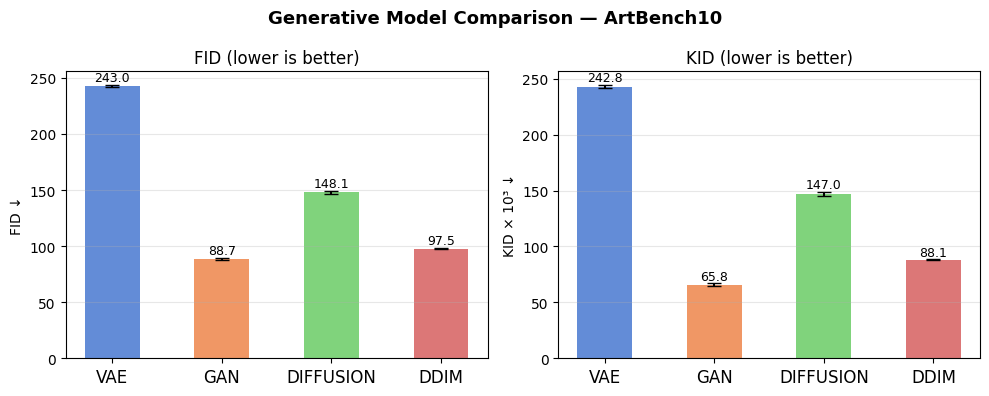

Saved: c:\Users\User\source\repos\genai-project1\drive_outputs\runs\figures\fid_kid_comparison.png

--- LaTeX table ---
\begin{table}[h]
\centering
\begin{tabular}{lrr}
\hline
Model & FID $\downarrow$ & KID $\times 10^{-3}$ $\downarrow$ \\
\hline
VAE & $242.98 \pm 0.69$ & $242.84 \pm 1.49$ \\
DCGAN & $88.68 \pm 0.87$ & $65.78 \pm 1.15$ \\
DDPM & $148.08 \pm 1.27$ & $146.96 \pm 1.67$ \\
DDIM & $97.50 \pm 0.46$ & $88.09 \pm 0.55$ \\
\hline
\end{tabular}
\caption{FID and KID results on ArtBench10 (20\% subset, 100 epochs).}
\label{tab:results}
\end{table}


In [42]:
# Results Summary — FID/KID comparison figure + LaTeX table
import json as _json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

_runs = PROJECT_ROOT / "runs" if "PROJECT_ROOT" in globals() else Path("runs")
_fig_dir = _runs / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
_results_path = _runs / "evaluation_results.json"

if not _results_path.exists():
    print("evaluation_results.json not found — run evaluation cell first.")
else:
    with open(_results_path) as f:
        res = _json.load(f)

    model_order = [k for k in ["vae", "gan", "diffusion", "ddim"] if k in res]
    labels      = [m.upper() for m in model_order]
    fid_means   = [res[m]["fid_mean"]       for m in model_order]
    fid_stds    = [res[m]["fid_std"]        for m in model_order]
    kid_means   = [res[m]["kid_mean"] * 1e3 for m in model_order]
    kid_stds    = [res[m]["kid_std"]  * 1e3 for m in model_order]

    x = np.arange(len(labels))
    w = 0.5
    colors = ["#4878d0", "#ee854a", "#6acc65", "#d65f5f"][:len(labels)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    bars1 = ax1.bar(x, fid_means, width=w, yerr=fid_stds, capsize=5,
                    color=colors, alpha=0.85, ecolor="black")
    ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=12)
    ax1.set_ylabel("FID ↓"); ax1.set_title("FID (lower is better)")
    ax1.grid(True, alpha=0.3, axis="y")
    for bar, val, std in zip(bars1, fid_means, fid_stds):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 1,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9)

    bars2 = ax2.bar(x, kid_means, width=w, yerr=kid_stds, capsize=5,
                    color=colors, alpha=0.85, ecolor="black")
    ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=12)
    ax2.set_ylabel("KID × 10³ ↓"); ax2.set_title("KID (lower is better)")
    ax2.grid(True, alpha=0.3, axis="y")
    for bar, val, std in zip(bars2, kid_means, kid_stds):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9)

    fig.suptitle("Generative Model Comparison — ArtBench10", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(_fig_dir / "fid_kid_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_dir / 'fid_kid_comparison.png'}")

    # LaTeX table
    print("\n--- LaTeX table ---")
    print("\\begin{table}[h]")
    print("\\centering")
    print("\\begin{tabular}{lrr}")
    print("\\hline")
    print("Model & FID $\\downarrow$ & KID $\\times 10^{-3}$ $\\downarrow$ \\\\")
    print("\\hline")
    for m in model_order:
        r = res[m]
        name = m.upper().replace("GAN", "DCGAN").replace("DIFFUSION", "DDPM").replace("DDIM", "DDIM")
        print(f"{name} & ${r['fid_mean']:.2f} \\pm {r['fid_std']:.2f}$ & ${r['kid_mean']*1e3:.2f} \\pm {r['kid_std']*1e3:.2f}$ \\\\")
    print("\\hline")
    print("\\end{tabular}")
    print("\\caption{FID and KID results on ArtBench10 (20\\% subset, 100 epochs).}")
    print("\\label{tab:results}")
    print("\\end{table}")
